# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
from nds_toolbox.preprocessing.features import compute_wavelet

import seaborn as sns




In [2]:

FIG_WIDTH = 7.5
MY_FONT_SIZE = 9


plt.rcParams.update({
    # --- Fonts ---
    "font.family": "Arial",
    "font.size": MY_FONT_SIZE,

    # --- Legend ---
    "legend.fontsize": MY_FONT_SIZE,
    "legend.frameon": False,

    # --- Titles ---
    "figure.titlesize": MY_FONT_SIZE,
    "axes.titleweight": "normal",
    "axes.titlesize": MY_FONT_SIZE,

    # --- Axes ---
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": True,
    "axes.labelsize": MY_FONT_SIZE,

    # --- Lines & markers ---
    "lines.linewidth": 1.0,
    "lines.markersize": 0.7,

    # --- Ticks ---
    "xtick.labelsize": MY_FONT_SIZE,
    "ytick.labelsize": MY_FONT_SIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "axes.linewidth": 0.7,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    # Grid
    "axes.grid": False,
    "grid.linestyle": ":",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.5,


    # --- Layout ---
    "figure.autolayout": True,

    # --- DPI ---
    "savefig.dpi": 900,
    "figure.dpi": 300,
})


# 2-state scenario

In [3]:
sim_cond = "2states"
signal_dir = "../data/simulations"
sim_data = np.load(f'{signal_dir}/{sim_cond}_data.npz', allow_pickle=True)

#load the simulated data
signal_sample = sim_data['signal_sample']
states_sample = sim_data['states_sample']

print("shape of signal_sample", signal_sample.shape)


performance_dir = "../data/performance"
file_path = f"{performance_dir}/{sim_cond}_results.pkl"

import pickle
with open(file_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df = pd.concat(df_list, axis = 0, ignore_index = True)
df.head()


shape of signal_sample (5, 5, 3)


,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id
0,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 1.1864136, 'weights': [0.5664814, 0....",1.0383563,3.0,1.294949e+09,...,0.703789,42.630307,2,3,"[0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, ...","[1, 0]",None,0.335422,1.0383563,NaN
1,HMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'initial_probs': [0.30523705, 0.69476295], 't...",0.966394,NaN,NaN,...,0.222408,25.507082,2,3,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0]",None,0.361506,0.966394,6.0
2,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 1.3546937, 'weights': [0.5758428, 0....",0.920575,6.0,3.662778e+09,...,0.485350,45.494302,2,7,"[0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, ...","[1, 0]",None,0.621023,0.920575,NaN
3,HMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'initial_probs': [0.84225214, 0.1577479], 'tr...",0.858959,NaN,NaN,...,0.135526,20.768653,2,7,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...","[1, 0]",None,0.783673,0.858959,0.0
4,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.7397532, 'weights': [0.6435321, 0....",0.87031615,1.0,1.065091e+08,...,0.457351,49.514931,2,11,"[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.746127,0.87031615,NaN


In [4]:
mean_df = pd.DataFrame(df.groupby(["method", "burst_f", "fs", "num_emb"]).mcc.agg(mean_mcc = "mean")).reset_index()
mean_df["window_size"] = 1/ mean_df["fs"].values * mean_df["num_emb"].values

print(mean_df.shape)
mean_df.head()

(390, 6)


,method,burst_f,fs,num_emb,mean_mcc,window_size
0,DP-GMM,10,100,3,0.196714,0.03
1,DP-GMM,10,100,7,0.612777,0.07
2,DP-GMM,10,100,11,0.725887,0.11
3,DP-GMM,10,100,15,0.790789,0.15
4,DP-GMM,10,100,19,0.826791,0.19


In [5]:

palette = sns.color_palette("viridis", n_colors=mean_df['num_emb'].nunique())

print(palette)
print(mean_df["num_emb"].unique())

[(0.28291, 0.105393, 0.426902), (0.275191, 0.194905, 0.496005), (0.248629, 0.278775, 0.534556), (0.212395, 0.359683, 0.55171), (0.180629, 0.429975, 0.557282), (0.153364, 0.497, 0.557724), (0.127568, 0.566949, 0.550556), (0.122312, 0.633153, 0.530398), (0.175707, 0.6979, 0.491033), (0.288921, 0.758394, 0.428426), (0.449368, 0.813768, 0.335384), (0.626579, 0.854645, 0.223353), (0.814576, 0.883393, 0.110347)]
[ 3  7 11 15 19 23 27 31 35 39 43 47 51]


In [6]:

mean_df.burst_f.unique()

array([10, 20, 30, 40, 50])

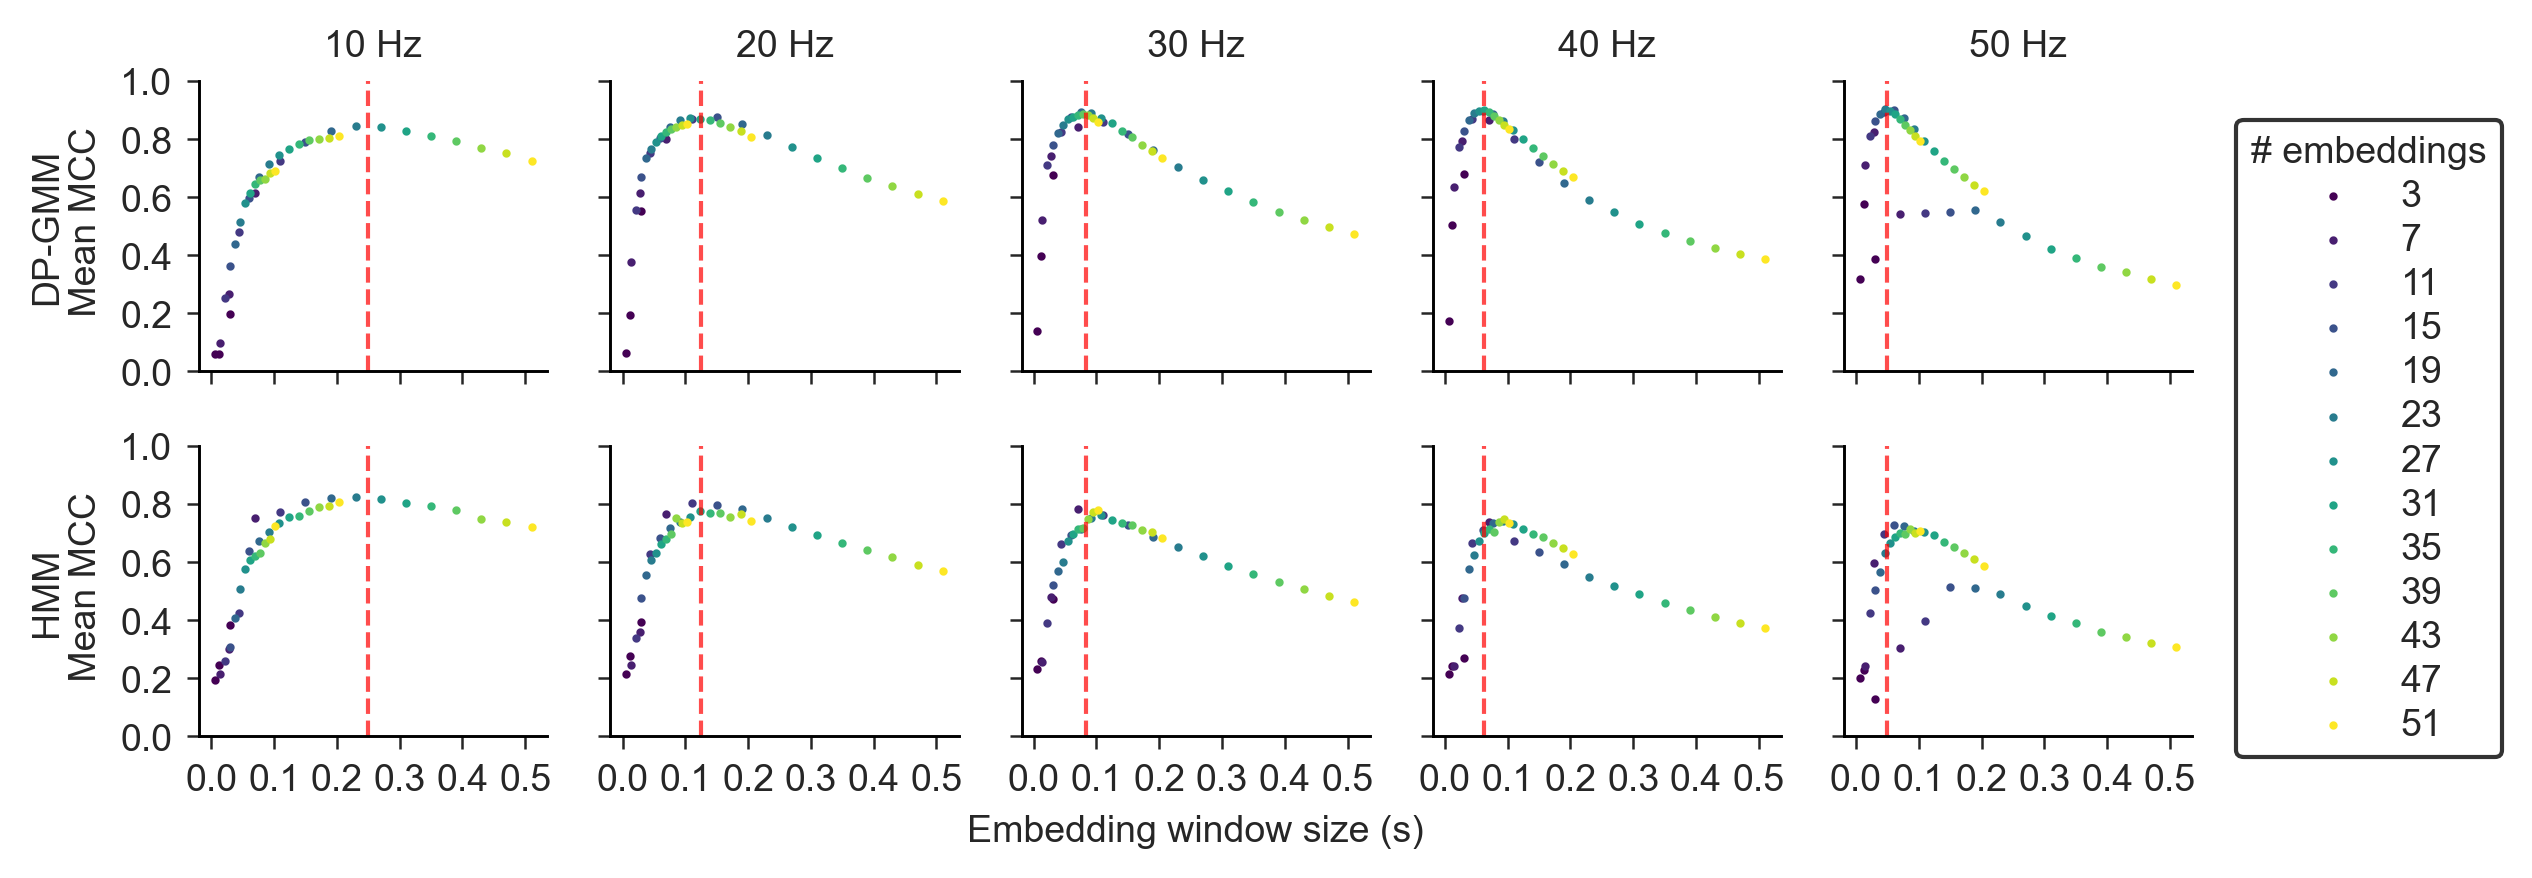

In [25]:
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator

plt.rcParams["axes.edgecolor"] = "black"

cmap = plt.get_cmap("viridis")
palette = [cmap(i / (mean_df['num_emb'].nunique() - 1))
           for i in range(mean_df['num_emb'].nunique())]

# Get unique values for faceting
methods = mean_df["method"].unique()
burst_fs = mean_df["burst_f"].unique()
num_embs = mean_df["num_emb"].unique()

# Prepare figure and axes (rows x cols)
fig, axes = plt.subplots(len(methods), len(burst_fs),
                         figsize=(FIG_WIDTH, 3),
                         sharex = True, sharey=True)


for i, method in enumerate(methods):
    for j, bf in enumerate(burst_fs):
        ax = axes[i, j]

        sub_df = mean_df[(mean_df["method"] == method) & (mean_df["burst_f"] == bf)]

        ax.yaxis.set_major_locator(MultipleLocator(0.2))
        #x.yaxis.set_minor_locator(MultipleLocator(0.1))
        ax.xaxis.set_major_locator(MultipleLocator(0.1))
        ax.tick_params(axis="both", which="major", labelsize=8)

        ax.set_ylim(0, 1)

        ax.axvline(
            x=2.5 / bf, #2 cycles of the corresponding bursts
            color="red",
            linestyle="--",
            linewidth=1.,
            alpha=0.7)


        for k, emb in enumerate(num_embs):
            df_emb = sub_df[sub_df["num_emb"] == emb]
            ax.scatter(df_emb["window_size"], df_emb["mean_mcc"],
                       color=palette[k], label=f"{emb}", s=1)

            #ax.grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.5)


        if i == 0:
            ax.set_title(f"{bf} Hz")

        if j == 0:
            ax.set_ylabel(f"{method}\n Mean MCC")

axes[1,2].set_xlabel("Embedding window size (s)")


handles, labels = ax.get_legend_handles_labels()

legend = fig.legend(handles, labels, title="# embeddings",
           loc="center right",
           bbox_to_anchor=(1.1, 0.5),  # position to the right
           borderaxespad=-1,
                    labelspacing = 0.27,
           ncol=1,
           frameon=True,)

legend.get_frame().set_edgecolor("black")



plt.tight_layout()


fig.savefig(
    f"../figures/raw_figure/{sim_cond}_results.png",
    bbox_inches="tight",
    pad_inches=0.05,)



plt.show()


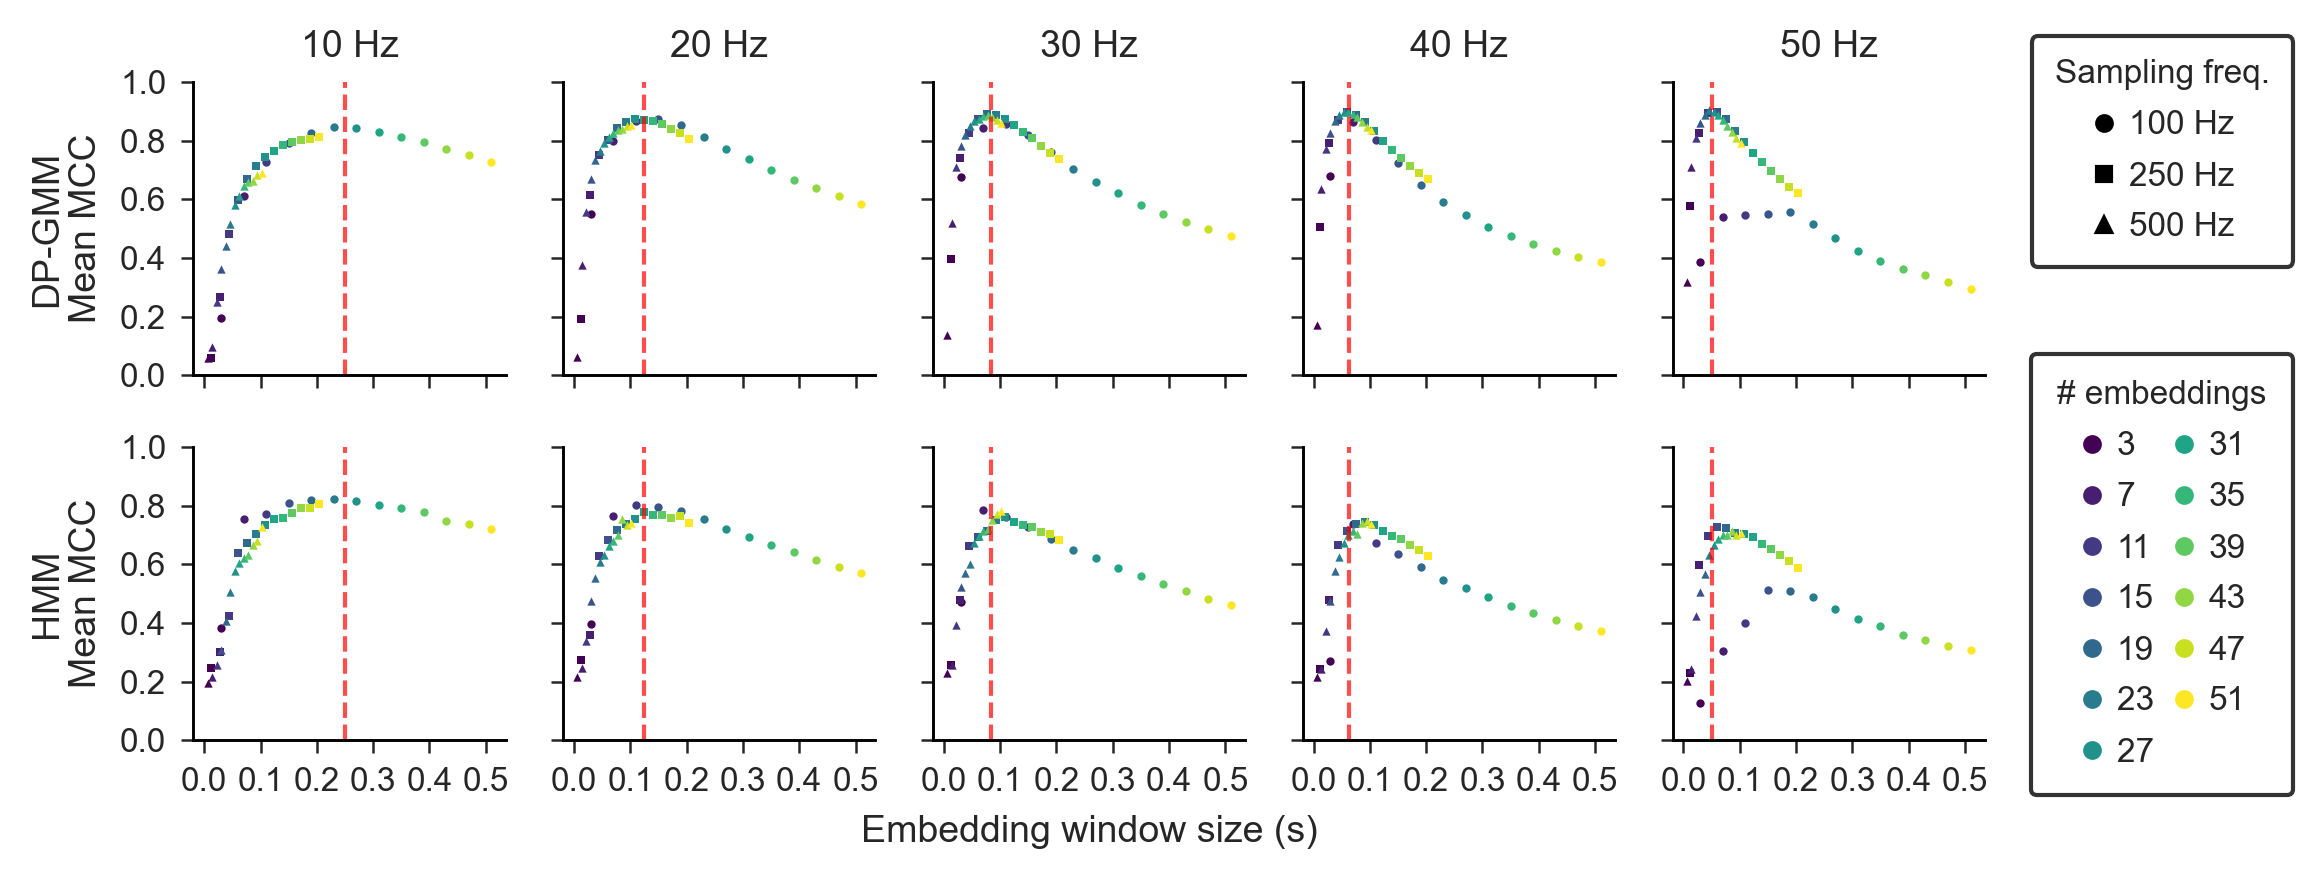

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator

plt.rcParams["axes.edgecolor"] = "black"

# =========================
# CONFIG
# =========================
TRUTH_CYCLES = 2.5          # vertical red line at TRUTH_CYCLES / burst_f (seconds)
SCATTER_SIZE = 4            # points in panels
LEG_FSIZE = 8
TITLE_FSIZE = 8
LEG_MARKERSIZE = 3.5        # marker size inside legends
RIGHT_MARGIN = 0.8         # reserve space for legends (tune 0.78–0.86)
ANCHOR_X = 0.91             # legend x position (keep near 1.0 to avoid wide save)

# =========================
# STABLE ORDERING
# =========================
methods   = list(mean_df["method"].dropna().unique())
burst_fs  = np.sort(mean_df["burst_f"].dropna().unique())
num_embs  = np.sort(mean_df["num_emb"].dropna().unique())
fs_levels = np.sort(mean_df["fs"].dropna().unique())

# =========================
# COLOR PALETTE (num_emb)
# =========================
cmap = plt.get_cmap("viridis")
if len(num_embs) == 1:
    palette = {num_embs[0]: cmap(0.5)}
else:
    palette = {emb: cmap(i / (len(num_embs) - 1)) for i, emb in enumerate(num_embs)}

# =========================
# MARKER MAP (fs)
# =========================
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h"]
if len(fs_levels) > len(marker_cycle):
    raise ValueError(f"Too many fs levels ({len(fs_levels)}). Add more markers.")
marker_map = {fs: marker_cycle[i] for i, fs in enumerate(fs_levels)}

# =========================
# FIGURE
# =========================
fig, axes = plt.subplots(
    len(methods), len(burst_fs),
    figsize=(FIG_WIDTH+1, 3),   # you control FIG_WIDTH externally
    sharex=True, sharey=True
)
axes = np.atleast_2d(axes)

# =========================
# PLOTTING
# =========================
for i, method in enumerate(methods):
    for j, bf in enumerate(burst_fs):
        ax = axes[i, j]
        sub_df = mean_df[(mean_df["method"] == method) & (mean_df["burst_f"] == bf)]

        ax.yaxis.set_major_locator(MultipleLocator(0.2))
        ax.xaxis.set_major_locator(MultipleLocator(0.1))
        ax.tick_params(axis="both", which="major", labelsize=8)
        ax.set_ylim(0, 1)

        # reference: TRUTH_CYCLES cycles of the simulated burst frequency
        ax.axvline(
            x=TRUTH_CYCLES / bf,
            color="red",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7
        )

        # color encodes num_emb, shape encodes fs
        for (emb, fs), g in sub_df.groupby(["num_emb", "fs"], dropna=False):
            ax.scatter(
                g["window_size"], g["mean_mcc"],
                color=palette[emb],
                marker=marker_map[fs],
                s=SCATTER_SIZE,
                linewidths=0
            )

        if i == 0:
            ax.set_title(f"{bf:g} Hz")
        if j == 0:
            ax.set_ylabel(f"{method}\nMean MCC")

# x-label: bottom row, middle column
axes[-1, len(burst_fs)//2].set_xlabel("Embedding window size (s)")

# =========================
# LAYOUT: reserve legend strip on the right
# =========================
fig.subplots_adjust(right=RIGHT_MARGIN)
plt.tight_layout(rect=[0, 0, RIGHT_MARGIN, 1])

# =========================
# LEGENDS (your version)
# =========================
emb_handles = [
    mlines.Line2D(
        [], [], color=palette[emb], marker="o", linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(emb)}"
    )
    for emb in num_embs
]

leg1 = fig.legend(
    handles=emb_handles,
    title="# embeddings",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.35),
    ncol=2,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.8,
    labelspacing=0.60,
    handletextpad=0.35,
    columnspacing=0.50,
    handlelength=0.8
)
leg1.get_frame().set_edgecolor("black")

fs_handles = [
    mlines.Line2D(
        [], [], color="black", marker=marker_map[fs], linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(fs)} Hz"
    )
    for fs in fs_levels
]

leg2 = fig.legend(
    handles=fs_handles,
    title="Sampling freq.",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.82),
    ncol=1,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.7,
    labelspacing=0.60,
    handletextpad=0.35,
    handlelength=0.8
)
leg2.get_frame().set_edgecolor("black")

# =========================
# SAVE + SHOW
# =========================
fig.savefig(
    f"../figures/raw_figure/{sim_cond}_results.png",
    bbox_inches="tight",
    pad_inches=0.05,
)

plt.show()


# 3-state scenario

In [3]:
from nds_toolbox.preprocessing.features import choose_embedding_dim, trim_data


fs = 250         # Sampling frequency in Hz.
n_seconds = 60   # Total duration in seconds.
time_vec = np.linspace(0, n_seconds, int(fs * n_seconds))


# Condition 1: frequency distances (3 states)
freqs_dist_range = [[10, 40], [15, 40], [20, 40], [25, 40], [30, 40],[35, 40]]  #30, 25, 20, 15, 10, 5Hz diff

# Condition 2: Signal-to-noise ratio (in dB)
snr_range = np.arange(-10, 11, 2)  # varying SNRs from -10 to 10 dB




In [5]:


# Condition 2: Signal-to-noise ratio (in dB)
snr_range = np.arange(-10, 11, 2)  # varying SNRs from -10 to 10 dB


sim_cond = "3states"
signal_dir = "../data/simulations"
sim_data = np.load(f'{signal_dir}/{sim_cond}_data.npz')


#load the simulated data
signal_sample = sim_data['signal_sample']
states_sample = sim_data['states_sample']
bursts_sample = sim_data['bursts_sample']

print("shape of signal_sample", signal_sample.shape)

shape of signal_sample (5, 6, 11, 45000)


In [6]:

performance_dir = "../data/performance"
file_path = f"{performance_dir}/{sim_cond}_results.pkl"

import pickle
with open(file_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df_3states = pd.concat(df_list, axis = 0, ignore_index = True)

df_3states["burst_f"] = df_3states["burst_f"].apply(tuple)

df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id
0,DP-GMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'alpha': 1481.1799, 'weights': [0.0002643804,...",0.74750763,4.0,1.221368e+09,...,0.600014,84.720967,3,25,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 2, 0]",None,0.004152,0.74750763,NaN
1,DP-GMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'alpha': 1481.1799, 'weights': [0.0002643804,...",0.74750763,4.0,1.221368e+09,...,0.600014,84.720967,3,25,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 2, 0]",None,0.000000,0.74750763,NaN
2,HMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,0.111238,38.693617,3,25,"[2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.024007,0.722242,5.0
3,HMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,0.111238,38.693617,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.021481,0.722242,5.0
4,Thresholding,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,0.001223,2.789531,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.198367,"[[0.4, 0.4], [0.4, 0.4]]",NaN


In [7]:
num_states = 3
snr_db = 0
snr_id = np.where(snr_range == snr_db)[0][0]
plot_f = (20, 40)
freq_id = np.where((np.array(freqs_dist_range) == np.array(plot_f)).all(axis=1))[0][0]

sample_id = 0

res = df_3states.query("burst_f == @plot_f and snr == @snr_db")
dpgmm_res = res.query("method == 'DP-GMM (Imputed)'").iloc[sample_id]
hmm_res = res.query("method == 'HMM (Imputed)'").iloc[sample_id]
thresh_res = res.query("method == 'Thresholding (Imputed)'").iloc[sample_id]


num_emb = int(res.num_emb.values[0])


dpgmm_states =dpgmm_res.est_states
dpgmm_mcc = dpgmm_res.mcc
dpgmm_states_onehot = np.eye(num_states)[dpgmm_states]

hmm_states = hmm_res.est_states
hmm_mcc = hmm_res.mcc
hmm_states_onehot = np.eye(num_states)[hmm_states]

thresh_states = thresh_res.est_states
thresh_mcc = thresh_res.mcc
thresh_states_onehot = np.eye(num_states)[thresh_states]





trimmed_signal = trim_data(signal_sample[sample_id, freq_id, snr_id], num_emb)
trimmed_states = trim_data(states_sample[sample_id, freq_id, snr_id], num_emb).astype(int)
trimmed_bursts = trim_data(bursts_sample[sample_id, freq_id, snr_id], num_emb)


trimmed_time_vec = np.linspace(0, len(trimmed_states)/fs, len(trimmed_states))
states_onehot = np.eye(num_states)[trimmed_states]

Lost 10 data points were lost from both ends.
data shape: (44980,)
Lost 10 data points were lost from both ends.
data shape: (44980,)
Lost 10 data points were lost from both ends.
data shape: (44980,)


In [18]:
df_avg = (
    df_3states.query("burst_f == @plot_f")
    .groupby(["method", "snr"], as_index = False)
    .agg(
        mcc_mean = ("mcc", "mean"),
        mcc_sem = ("mcc", lambda x: np.std(x, ddof = 1) / np.sqrt(len(x))),
        mcc_std = ("mcc", "std"),))



In [19]:
df_3states.method.values


array(['DP-GMM', 'DP-GMM (Imputed)', 'HMM', ..., 'HMM (Imputed)',
       'Thresholding', 'Thresholding (Imputed)'],
      shape=(1980,), dtype=object)

In [20]:
def relabel_freqs(burst_f):
    f0, f1 = burst_f 
    label = f"{str(f0)}&{str(f1)}"
    return label


df_3states["burst_f"] = df_3states["burst_f"].apply(relabel_freqs)


/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_29629/219063976.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


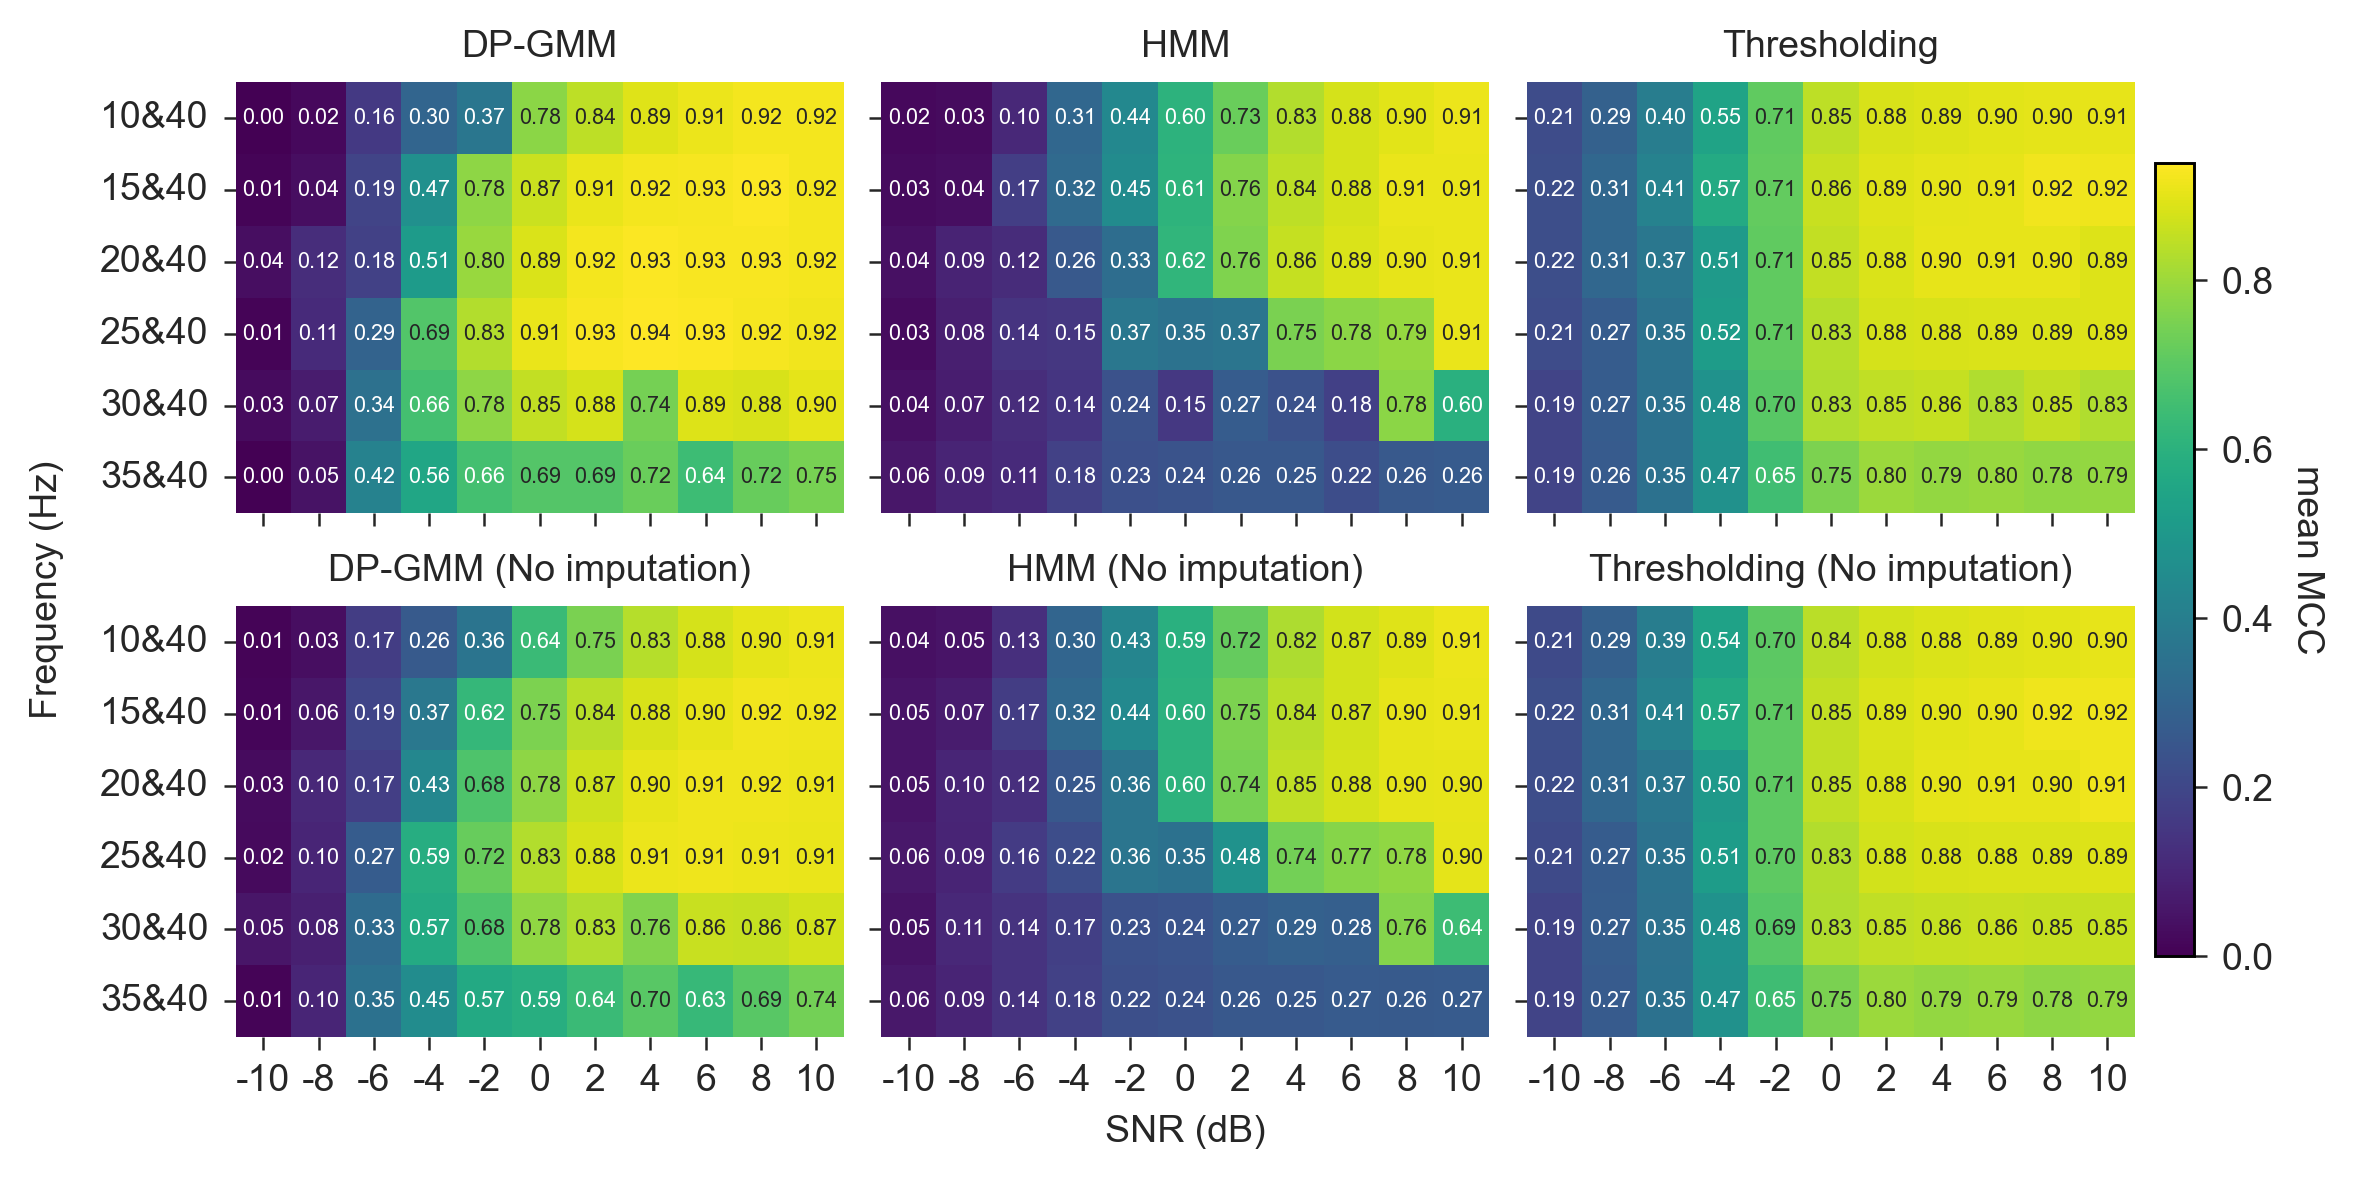

In [22]:
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MaxNLocator



method_names = set(df_3states.method.values)



dpgmm_heat = (df_3states.query("method == 'DP-GMM'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="mean")
        .sort_index(axis=0) 
        .sort_index(axis=1))

hmm_heat = (df_3states.query("method == 'HMM'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="mean")
        .sort_index(axis=0)   # freq ascending
        .sort_index(axis=1))  # snr ascending



thresh_heat = (df_3states.query("method == 'Thresholding'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="mean")
        .sort_index(axis=0) 
        .sort_index(axis=1))




dpgmm_imputed_heat = (df_3states.query("method == 'DP-GMM (Imputed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="mean")
        .sort_index(axis=0) 
        .sort_index(axis=1))


hmm_imputed_heat = (df_3states.query("method == 'HMM (Imputed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="mean")
        .sort_index(axis=0)   # freq ascending
        .sort_index(axis=1))  # snr ascending


thresh_imputed_heat = (df_3states.query("method == 'Thresholding (Imputed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="mean")
        .sort_index(axis=0) 
        .sort_index(axis=1))




mats = [
    dpgmm_heat, hmm_heat, thresh_heat,
    dpgmm_imputed_heat, hmm_imputed_heat, thresh_imputed_heat
]

vmin = np.nanmin([m.to_numpy() for m in mats])
vmax = np.nanmax([m.to_numpy() for m in mats])




common = dict(
    annot=True, fmt=".2f", annot_kws={"size": 5.2},
    cmap="viridis", vmin=vmin, vmax=vmax,
    cbar=False
)


fig, ax = plt.subplots(2, 3, figsize=(FIG_WIDTH, 4), sharex=True, sharey=True)

sns.heatmap(dpgmm_imputed_heat, **common, ax=ax[0,0])
ax[0,0].set_title("DP-GMM")

sns.heatmap(hmm_imputed_heat, **common, ax=ax[0,1])
ax[0,1].set_title("HMM")

sns.heatmap(thresh_imputed_heat, **common, ax=ax[0,2])
ax[0,2].set_title("Thresholding")

sns.heatmap(dpgmm_heat, **common, ax=ax[1,0])
ax[1,0].xaxis.set_major_locator(MaxNLocator(6))
ax[1,0].set_title("DP-GMM (No imputation)")

sns.heatmap(hmm_heat, **common, ax=ax[1,1])
ax[1,1].set_title("HMM (No imputation)")

sns.heatmap(thresh_heat, **common, ax=ax[1,2])
ax[1,2].set_title("Thresholding (No imputation)")






sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap="viridis")
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax.ravel().tolist(), fraction=0.02, pad=-0.05)
cbar.set_label("mean MCC",  rotation=270, labelpad=12)




for a in ax.flat:
    a.set_xlabel("")
    a.set_ylabel("")
    

fig.supylabel("Frequency (Hz)", fontsize = MY_FONT_SIZE)

ax[1,1].set_xlabel("SNR (dB)", fontsize = MY_FONT_SIZE)


plt.tight_layout()

fig.savefig(
    f"../figures/raw_figure/{sim_cond}heatmaps.jpg",
    bbox_inches="tight"
)





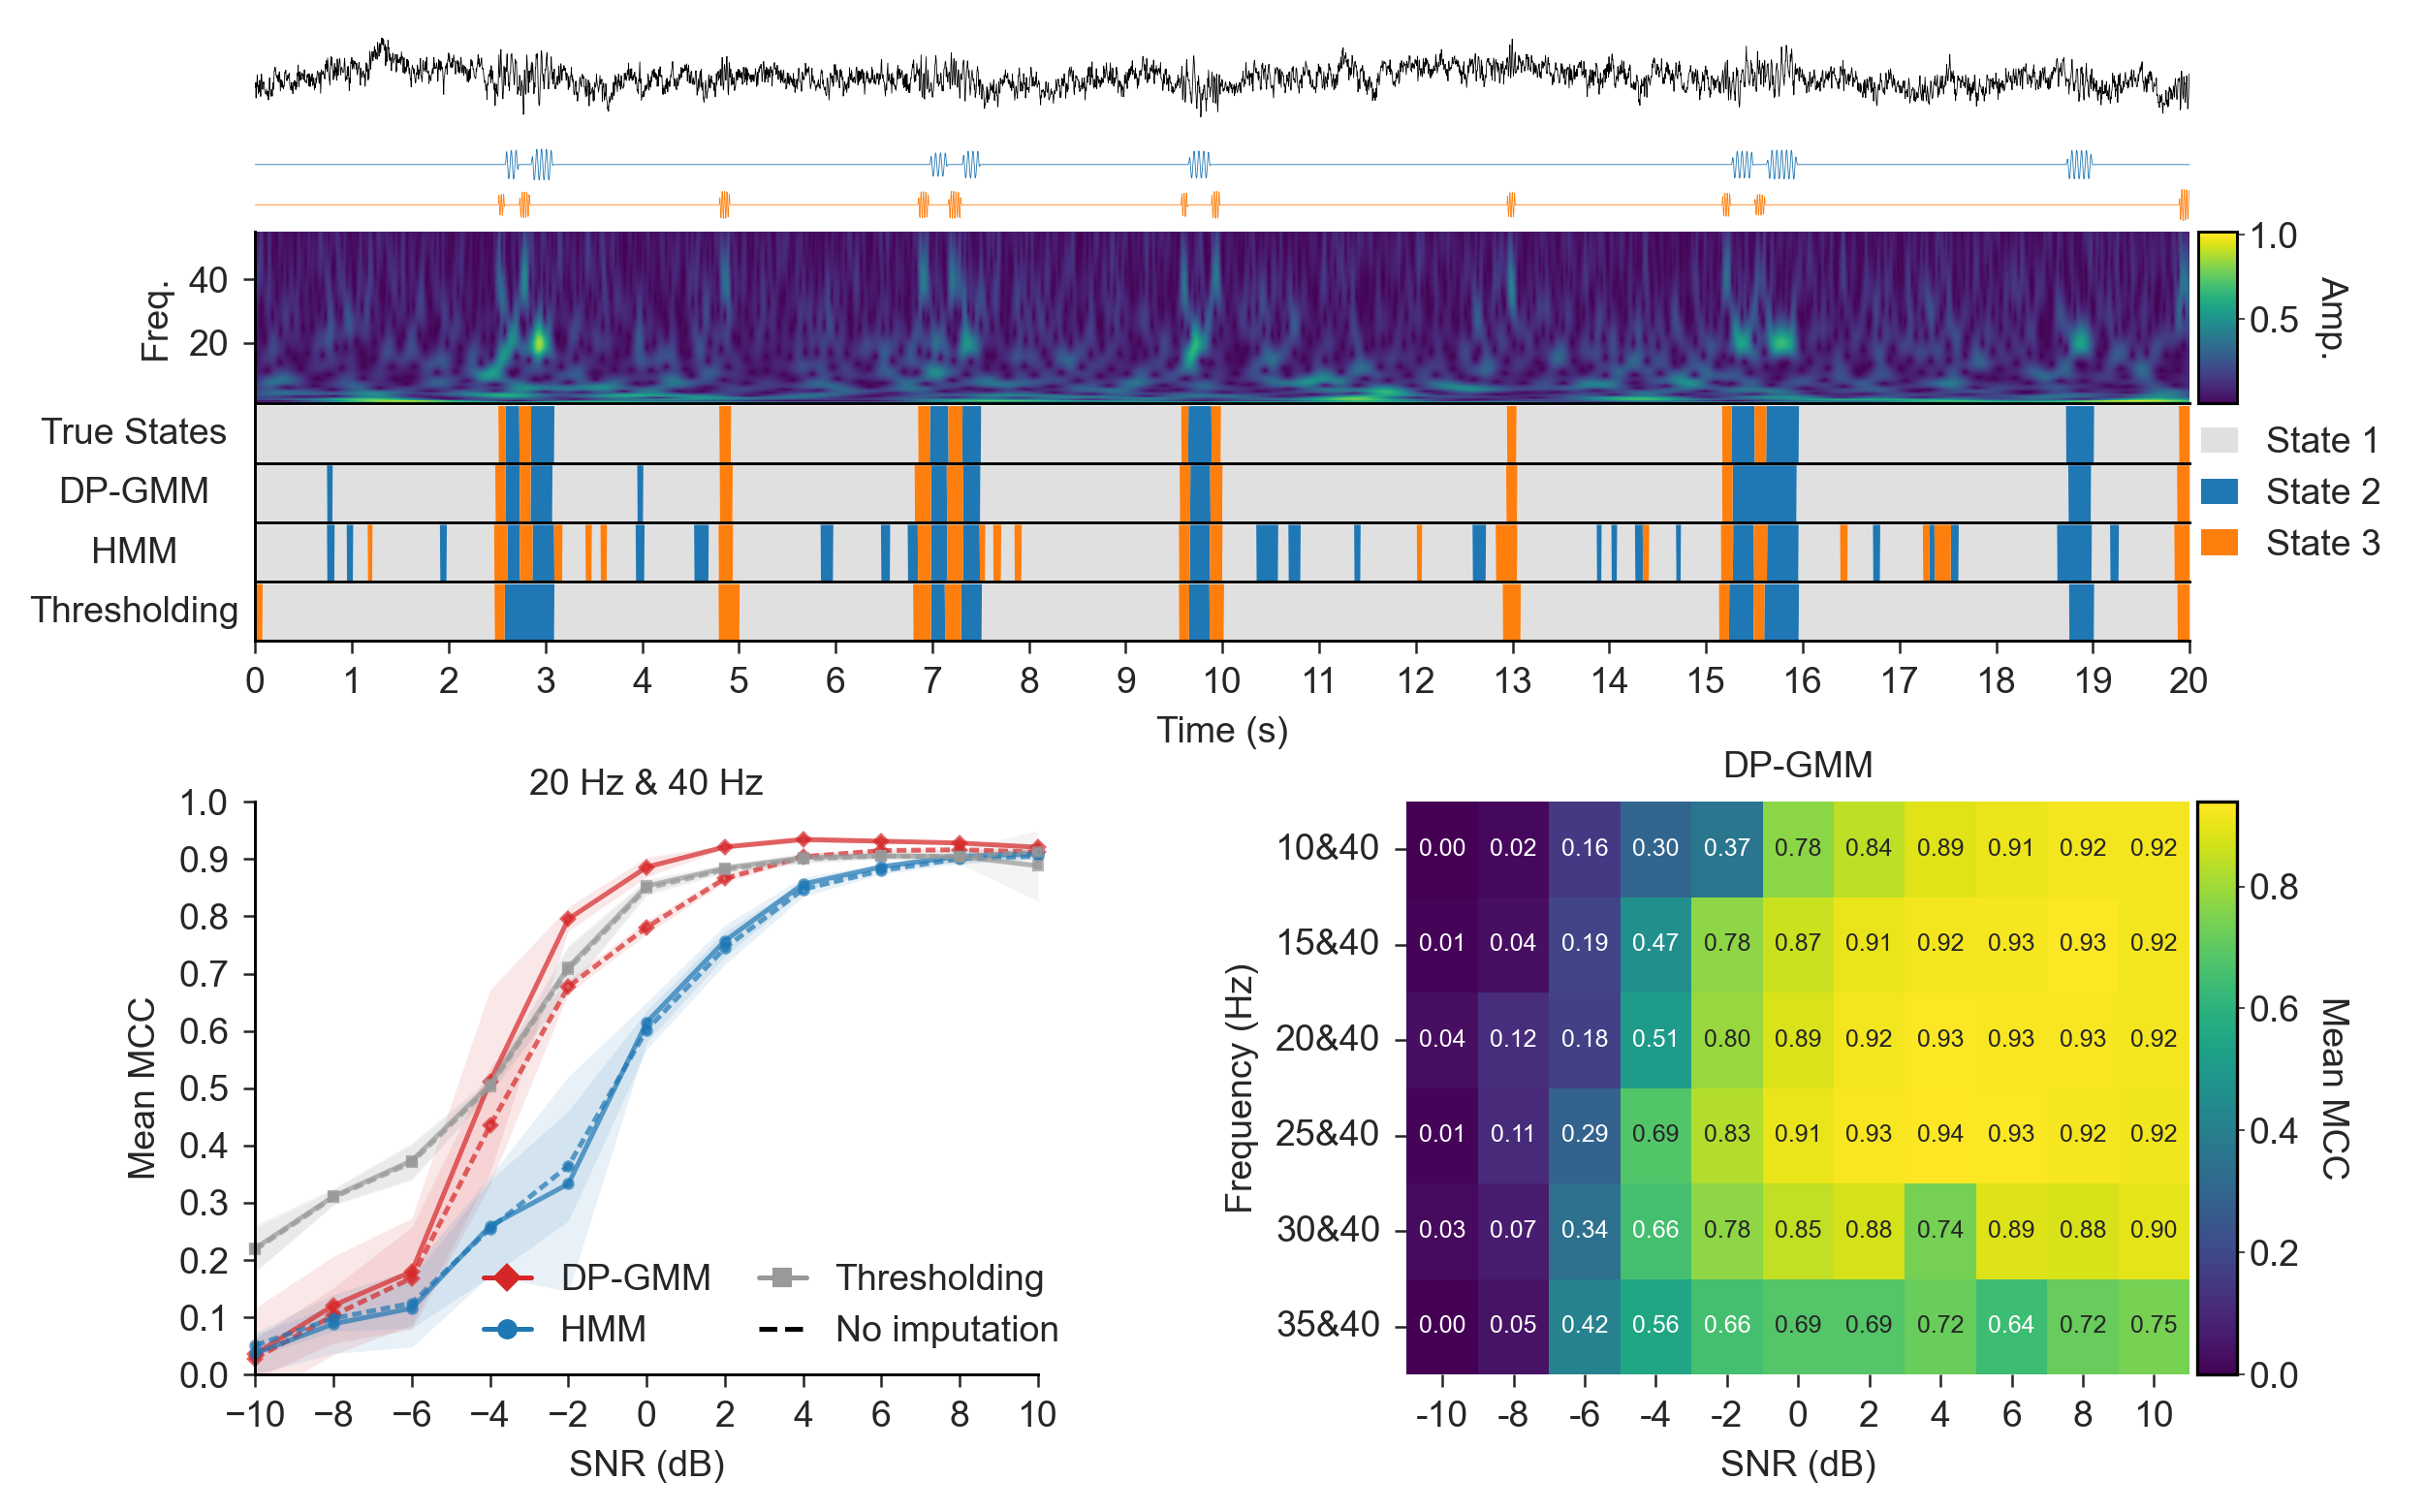

In [28]:

plt.close("all")

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D







plot_t = 20
#compute wavelet
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")






cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i+1}" for i in range(num_states)]



mosaic = [["b1", "b1"],
          ["b2", "b2"],
          ["b3", "b3"],
          ["b4", "b4"],
          ["b5", "b5"],
          ["b6", "b6"],
          ["a", "c"]
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 5),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.2,0.2, 0.2,0.2,2]}
)
fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)




thresh_color = "#999999" # grey
hmm_color   = "#1f77b4"  # vivid blue
dpgmm_color   = "#d62728"

palette = {
    "Thresholding":                 thresh_color,
    "Thresholding (Imputed)":     thresh_color,
    "HMM":                   hmm_color,
    "HMM (Imputed)":       hmm_color,
    "DP-GMM":                 dpgmm_color,
    "DP-GMM (Imputed)":     dpgmm_color,
}

dashes = {
    "Thresholding":               (2, 1),      # dashed
    "Thresholding (Imputed)":   (None, None),# solid
    "HMM":                 (2, 1),
    "HMM (Imputed)":     (None, None),
    "DP-GMM":               (2, 1),
    "DP-GMM (Imputed)":   (None, None),
}

markers = {
    "Thresholding":               "s",   # square
    "Thresholding (Imputed)":   "s",
    "HMM":                 "o",   # circle
    "HMM (Imputed)":     "o",
    "DP-GMM":               "D",   # diamond
    "DP-GMM (Imputed)":   "D",
}


handles_left = [
    Line2D([0], [0], color=dpgmm_color, marker="D", lw=1.2, ms=4, linestyle="-", label="DP-GMM"),
    Line2D([0], [0], color=hmm_color, marker="o", lw=1.2, ms=4, linestyle="-", label="HMM"),
    Line2D([0], [0], color=thresh_color, marker="s", lw=1.2, ms=4, linestyle="-", label="Thresholding"),
]

handles_right = [
    Line2D([0], [0], color="k", lw=1.2, linestyle="--", label="No imputation")  # dashed example
]
handles = handles_left + handles_right
labels  = [h.get_label() for h in handles]

axes["a"].legend(
    handles, labels,
    ncols=2,
    loc="best",  # or adjust position
    frameon=False,
    bbox_to_anchor=(0.25, 0.25),
    columnspacing=1.3,
    handlelength=1.3
)



for method in df_avg["method"].unique():
    df_sub = df_avg[df_avg["method"] == method]
    label = method.replace("_", " ")
    axes["a"].plot(
        df_sub["snr"], df_sub["mcc_mean"],
        label=label,
        color=palette[method],
        marker=markers[method],
        linestyle='-' if dashes[method] == (None, None) else (0, dashes[method]),
        lw=1.2, ms=2, alpha=0.7, clip_on=False)
        # Shaded std band
    axes["a"].fill_between(
        df_sub["snr"],
        df_sub["mcc_mean"] - df_sub["mcc_std"],
        df_sub["mcc_mean"] + df_sub["mcc_std"],
        color=palette[method],
        alpha=0.1, clip_on=True,
        linewidth=0
    )
axes["a"].set_xticks(snr_range)
axes["a"].set_xlim(min(snr_range), max(snr_range))
axes["a"].set_ylim(0, 1)
axes["a"].yaxis.set_major_locator(MultipleLocator(0.1))
#axes["a"].yaxis.set_minor_locator(MultipleLocator(0.05))
#axes["a"].grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.5)
axes["a"].set_xlabel("SNR (dB)")
axes["a"].set_ylabel("Mean MCC")
axes["a"].set_title(f"{plot_f[0]} Hz & {plot_f[1]} Hz",pad = 0.3)




axes["b1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["b1"].grid(False)
axes["b1"].set_frame_on(False)
#axes["b1"].set_title(f"Raw signal (SNR = {snr_db} dB)", pad= 0.3)


axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -2+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1), lw=0.2, color=colors[1])
axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -3+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2), lw=0.2, color=colors[2])




axes["b1"].set_yticks([])
axes["b1"].set_xticks([])






for s in ("top","right","bottom","left"):
    axes["b1"].spines[s].set_visible(False)
axes["b1"].set_frame_on(False)
axes["b1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["b2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["b2"].set_ylabel("Freq.")
#axes["b2"].set_title("Wavelet Transform", pad = 0.3)





#axes["b2"].tick_params(axis='y', which='both', left=True, labelleft=True, l)
axes["b2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["b2"].yaxis.set_major_locator(MultipleLocator(20))

axes["b2"].set_ylim(1, 55)


cax = inset_axes(
    axes["b2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["b3"].stackplot(trimmed_time_vec[:plot_t*fs], states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["b3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")
axes["b3"].tick_params(axis='y', which='both', left=False, labelleft=False)


axes["b4"].stackplot(trimmed_time_vec[:plot_t*fs], dpgmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {dpgmm_mcc:.2f}"] + [None]*(num_states-1))
axes["b4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")



axes["b5"].stackplot(trimmed_time_vec[:plot_t*fs], hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {hmm_mcc:.2f}")
axes["b5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")

axes["b6"].stackplot(trimmed_time_vec[:plot_t*fs], thresh_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = f"MCC = {thresh_mcc:.2f}")
axes["b6"].set_ylabel(f"Thresholding", rotation = 0, labelpad=30, va="center")



for key in ["b3", "b4", "b5"]:
    axes[key].tick_params(axis='x', which='both', bottom=False, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    
for key in ["b1","b2", "b3", "b4", "b5", "b6"]:
    axes[key].sharex(axes["b1"])




axes["b6"].set_xlabel("Time (s)")
axes["b6"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["b6"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["b6"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["b6"].set_ylim(0, 1)
axes["b6"].set_xlim(0, plot_t)


axes["b6"].spines["bottom"].set_visible(True)   # keep x-axis frame


#axes["a"].tick_params(direction='in', length=3, width=0.4, bottom=True, left=True)

cax_heat = inset_axes(
    axes["c"],
    width="5%", height="100%",
    loc="center right",
    borderpad=-1.3
)

sns.heatmap(
    dpgmm_imputed_heat,
    annot=True, fmt=".2f", annot_kws={"size": 6},
    cmap="viridis", vmin=vmin, vmax=vmax,
    cbar=True, cbar_ax=cax_heat,
    ax=axes["c"]
)


cbar = axes["c"].collections[0].colorbar
cbar.set_label("Mean MCC", rotation=270, labelpad=12)
cbar.ax.tick_params(which="both", length=2, width=0.4, pad=1)
cbar.outline.set_visible(True)
cbar.outline.set_linewidth(0.8)

axes["c"].set_title("DP-GMM")
axes["c"].set_xlabel("SNR (dB)")
axes["c"].set_ylabel("Frequency (Hz)")






handles, labels = axes["b3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",
           bbox_to_anchor=(0.981, 0.68), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1)



cb.solids.set_edgecolor("face")
cbar.solids.set_edgecolor("face")


fig.savefig(
    f"../figures/raw_figure/{sim_cond}_results.jpg",
    bbox_inches="tight"
)





## performance before imputation

In [29]:

dpgmm_res = res.query("method == 'DP-GMM'").iloc[sample_id]
hmm_res = res.query("method == 'HMM'").iloc[sample_id]
thresh_res = res.query("method == 'Thresholding'").iloc[sample_id]


dpgmm_states =dpgmm_res.est_states
dpgmm_mcc = dpgmm_res.mcc
dpgmm_states_onehot = np.eye(num_states)[dpgmm_states]

hmm_states = hmm_res.est_states
hmm_mcc = hmm_res.mcc
hmm_states_onehot = np.eye(num_states)[hmm_states]

thresh_states = thresh_res.est_states
thresh_mcc = thresh_res.mcc
thresh_states_onehot = np.eye(num_states)[thresh_states]



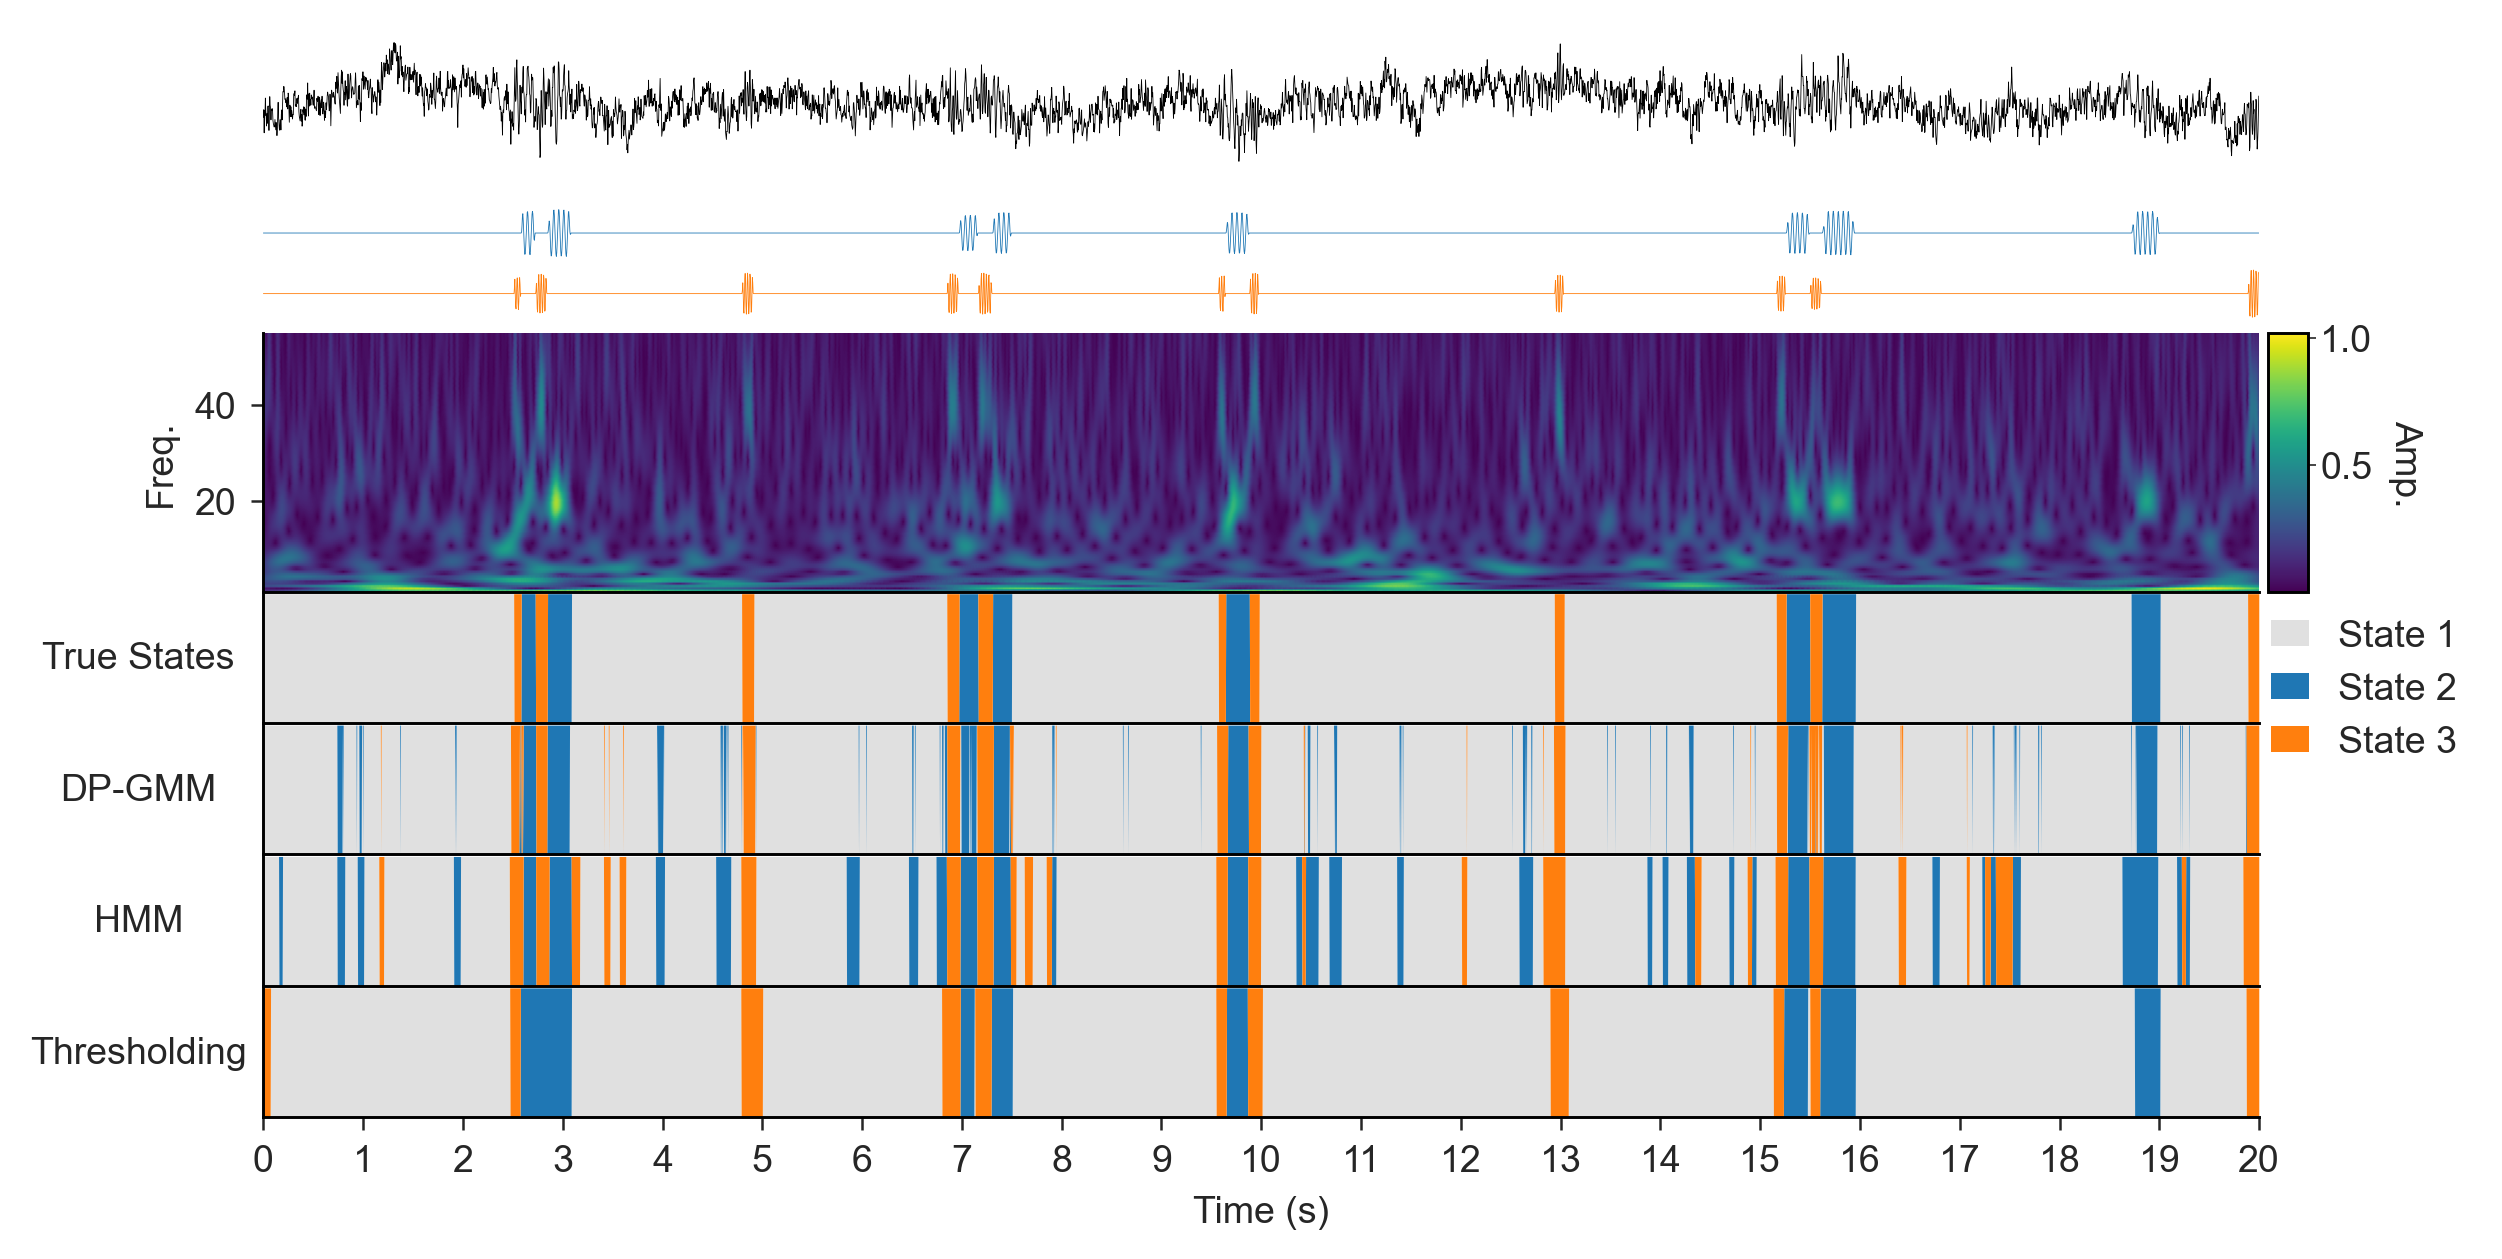

In [32]:


import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes







plot_t = 20
#compute wavelet
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")






cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i+1}" for i in range(num_states)]



mosaic = [["b1", "b1"],
          ["b2", "b2"],
          ["b3", "b3"],
          ["b4", "b4"],
          ["b5", "b5"],
          ["b6", "b6"],

         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 4),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.3,0.3, 0.3, 0.3]}
)
fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)





axes["b1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["b1"].grid(False)
axes["b1"].set_frame_on(False)
#axes["b1"].set_title(f"Raw signal (SNR = {snr_db} dB)", pad= 0.3)


axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -2+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1), lw=0.2, color=colors[1])
axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -3+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2), lw=0.2, color=colors[2])




axes["b1"].set_yticks([])
axes["b1"].set_xticks([])






for s in ("top","right","bottom","left"):
    axes["b1"].spines[s].set_visible(False)
axes["b1"].set_frame_on(False)
axes["b1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["b2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["b2"].set_ylabel("Freq.")
#axes["b2"].set_title("Wavelet Transform", pad = 0.3)





#axes["b2"].tick_params(axis='y', which='both', left=True, labelleft=True, l)
axes["b2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["b2"].yaxis.set_major_locator(MultipleLocator(20))

axes["b2"].set_ylim(1, 55)


cax = inset_axes(
    axes["b2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["b3"].stackplot(trimmed_time_vec[:plot_t*fs], states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["b3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")
axes["b3"].tick_params(axis='y', which='both', left=False, labelleft=False)


axes["b4"].stackplot(trimmed_time_vec[:plot_t*fs], dpgmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {dpgmm_mcc:.2f}"] + [None]*(num_states-1))
axes["b4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")



axes["b5"].stackplot(trimmed_time_vec[:plot_t*fs], hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {hmm_mcc:.2f}")
axes["b5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")

axes["b6"].stackplot(trimmed_time_vec[:plot_t*fs], thresh_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = f"MCC = {thresh_mcc:.2f}")
axes["b6"].set_ylabel(f"Thresholding", rotation = 0, labelpad=30, va="center")



for key in ["b3", "b4", "b5"]:
    axes[key].tick_params(axis='x', which='both', bottom=False, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    
for key in ["b1","b2", "b3", "b4", "b5", "b6"]:
    axes[key].sharex(axes["b1"])




axes["b6"].set_xlabel("Time (s)")
axes["b6"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["b6"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["b6"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["b6"].set_ylim(0, 1)
axes["b6"].set_xlim(0, plot_t)


axes["b6"].spines["bottom"].set_visible(True)   # keep x-axis frame






handles, labels = axes["b3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           bbox_to_anchor=(0.981, 0.45), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1)


fig.savefig(
    f"../figures/raw_figure/{sim_cond}_before_imputation.jpg",
    bbox_inches="tight"
)





# 4 states scenario

In [33]:
sim_cond = "4states"
data_dir = "../data/simulations"
data_file = f"{data_dir}/{sim_cond}_data.npz"


sim_data = np.load(data_file)

signal = sim_data["signal_sample"]
states = sim_data["states_sample"]
bursts = sim_data["bursts_sample"]


import pickle
performance_dir = "../data/performance"
save_path = os.path.join(performance_dir, f"{sim_cond}_res.pkl")

# Load
with open(save_path, "rb") as f:
    res = pickle.load(f)



In [34]:
res = pd.DataFrame(res)

In [35]:
from nds_toolbox.preprocessing.features import compute_tde, trim_data, choose_embedding_dim

In [36]:

n_seconds = 60*3  # Total duration in seconds.
fs = 250

snr_db = 2

freq = np.array([20, 30, 40])  #ground truth = 4 states (including noise state)
num_emb = choose_embedding_dim(np.mean(freq), fs, min_cycles = 2.5, ensure_odd = True)
tde_signal = compute_tde(signal, num_emb)



trimmed_states = trim_data(states, num_embeddings = num_emb, verbose = False)
trimmed_signal = trim_data(signal, num_embeddings = num_emb, verbose = False)
trimmed_bursts = trim_data(bursts, num_embeddings = num_emb, verbose = False)
trimmed_time_vec = np.linspace(0, len(trimmed_states)/fs, len(trimmed_states))




num_states = int(np.ceil(np.log(len(trimmed_signal))))
print(num_states)

Chosen window size = 0.083 (sec): minimum cycles of 2.5 at 30.0 Hz
Chosen embedding dimension = 21: sampling rate = 250 Hz
10 data points were lost from both ends.
data shape: (44980, 21)
11


In [37]:
res

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id
0,DP-GMM,"[-0.40889510725360423, -0.5254749820793517, 0....","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[20, 30, 40]",250,2,"{'alpha': 0.49975413, 'weights': [0.6987322, 0...",0.7603842,5.0,2.673126e+09,...,0.855147,269.170225,11,21,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[0, 5, 2, 4, 1, 3, 6, 7, 8, 9, 10]",{'fractional_occupancies': [0.7653846153846153...,0.869354,0.7603842,NaN
1,DP-GMM (Imputed),"[-0.40889510725360423, -0.5254749820793517, 0....","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[20, 30, 40]",250,2,"{'alpha': 0.49975413, 'weights': [0.6987322, 0...",0.7603842,5.0,2.673126e+09,...,0.855147,269.170225,11,21,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[0, 5, 2, 4, 1, 3, 6, 7, 8, 9, 10]","{'fractional_occupancies': [0.779546465095598,...",0.935072,0.7603842,NaN
2,HMM,"[-0.40889510725360423, -0.5254749820793517, 0....","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[20, 30, 40]",250,2,"{'initial_probs': [0.118541114, 0.056485035, 0...",0.696457,NaN,NaN,...,0.148423,261.137821,11,21,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[4, 10, 0, 5, 1, 2, 3, 6, 7, 8, 9]",{'fractional_occupancies': [0.1198755002223210...,0.348349,0.696457,0.0
3,HMM (Imputed),"[-0.40889510725360423, -0.5254749820793517, 0....","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[20, 30, 40]",250,2,"{'initial_probs': [0.118541114, 0.056485035, 0...",0.696457,NaN,NaN,...,0.148423,261.137821,11,21,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[4, 10, 0, 5, 1, 2, 3, 6, 7, 8, 9]","{'fractional_occupancies': [0.0, 0.18136949755...",0.311265,0.696457,0.0


In [39]:
res.query("method == 'DP-GMM'").est_params.values[0].keys()

dict_keys(['alpha', 'weights', 'means', 'covs', 'untrunc_means', 'untrunc_covs', 'untrunc_weights', 'trunc_info'])

In [40]:

from nds_toolbox.models.dpgmm_numpyro import truncate, get_states
from sklearn.metrics import matthews_corrcoef

In [41]:

gmm_states = res.query("method == 'DP-GMM (Imputed)'").est_states.to_numpy()[0]
gmm_states_onehot = np.eye(num_states)[gmm_states]
gmm_mcc = res.query("method == 'DP-GMM (Imputed)'").mcc.values[0]


gmm_sumary_stats = res.query("method == 'DP-GMM (Imputed)'")["summary_stats"].values[0]
gmm_fo = gmm_sumary_stats["fractional_occupancies"]
gmm_f, gmm_psds = gmm_sumary_stats["spectra"]



order_gmm = res.query("method == 'DP-GMM (Imputed)'").order.to_numpy()[0]
alpha, weights, gmm_means, gmm_covs, untrunc_means, untrunc_covs, untrunc_weights, trunc_info  = res.query("method == 'DP-GMM'").est_params.values[0].values()

#trunc_means, trunc_covs, trunc_weights = truncate(1, gmm_means, gmm_covs, weights, verbose = True)
#gmm_states = get_states(tde_signal, trunc_means, trunc_covs, trunc_weights)
#gmm_mcc = matthews_corrcoef(trimmed_states, gmm_states)


hmm_states = res.query("method == 'HMM (Imputed)'").est_states.to_numpy()[0]
hmm_states_onehot = np.eye(num_states)[hmm_states]
hmm_mcc = res.query("method == 'HMM (Imputed)'").mcc.values[0]

hmm_sumary_stats = res.query("method == 'HMM (Imputed)'")["summary_stats"].values[0]
#hmm_fo = hmm_sumary_stats["fractional_occupancies"]
hmm_f, hmm_psds = hmm_sumary_stats["spectra"]



order_hmm = res.query("method == 'HMM (Imputed)'").order.to_numpy()[0]
init_probs, trans_mat, hmm_means, hmm_covs, stationary_dist = res.query("method == 'HMM (Imputed)'").est_params.values[0].values()




/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_29629/3592749920.py:167: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  ax_b = inset_axes(axes["b"],
/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_29629/3592749920.py:198: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  ab_c = inset_axes(axes["c"],


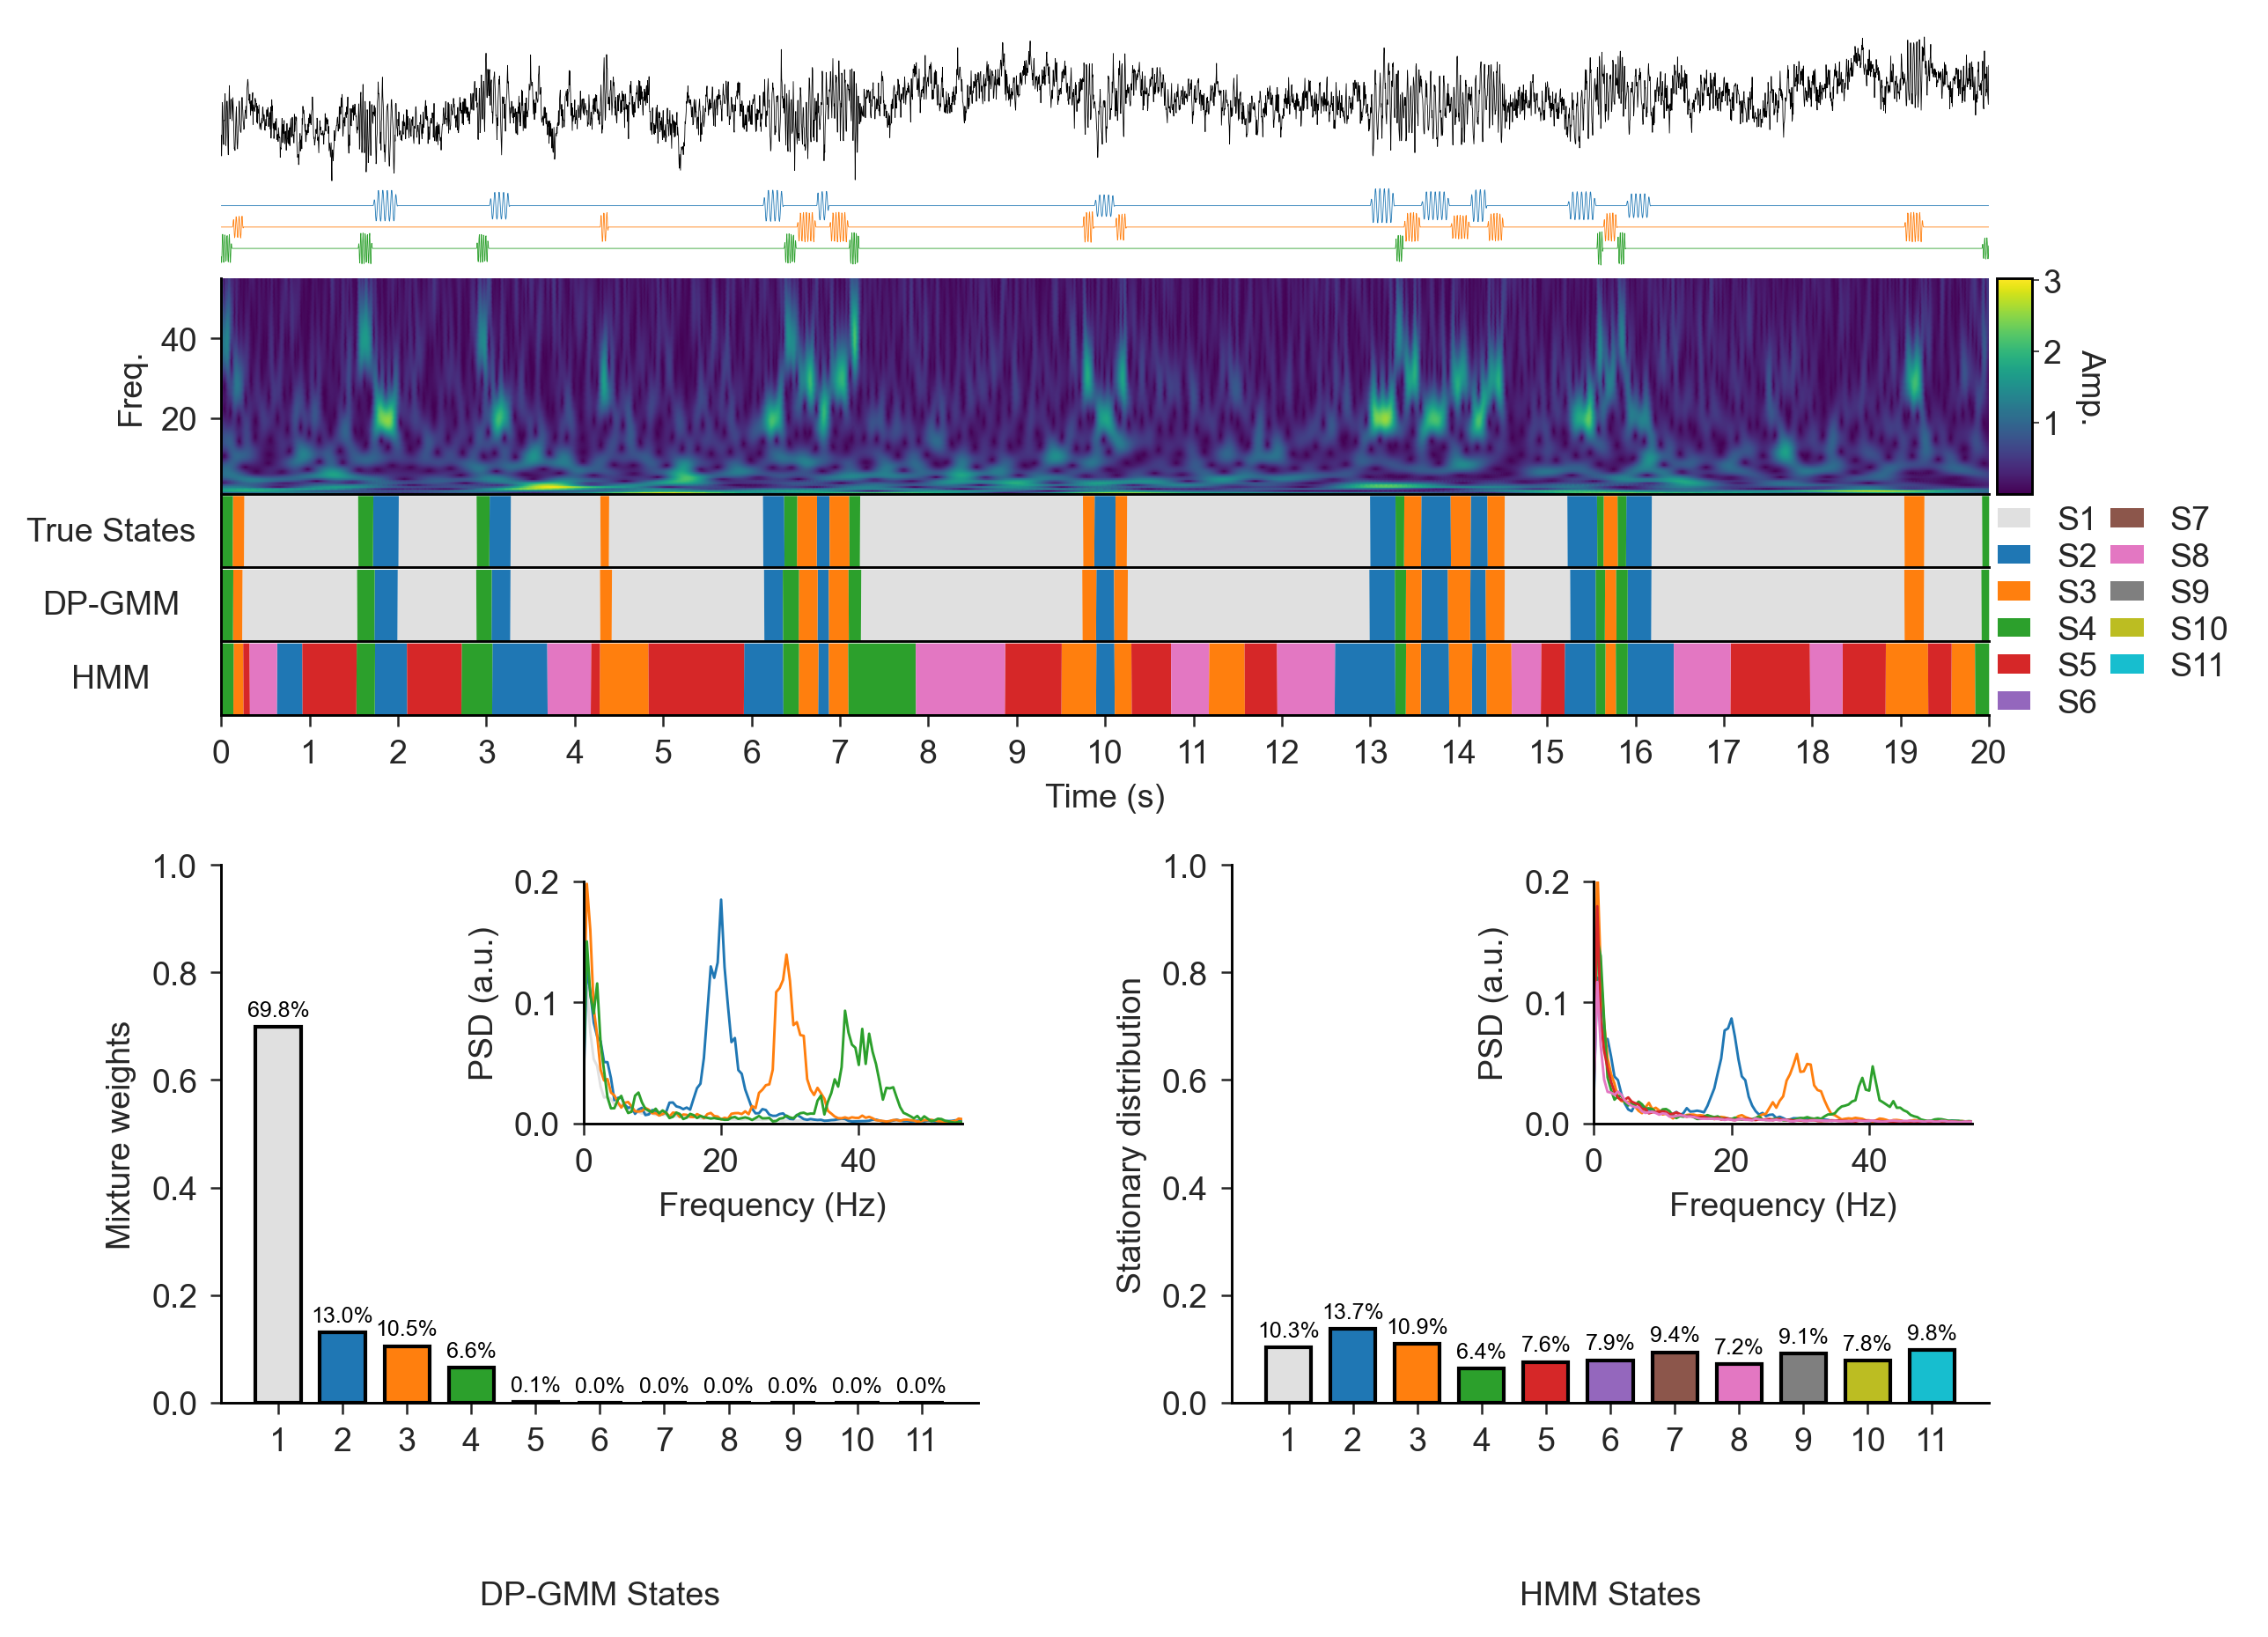

In [43]:

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"S{i+1}" for i in range(num_states)]

plot_t = 20


trimmed_states_onehot = np.eye(num_states)[trimmed_states]
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")

mosaic = [["a1", "a1"],
          ["a2", "a2"],
          ["a3", "a3"],
          ["a4", "a4"],
          ["a5", "a5"],
          ["gap", "gap"],
          ["c", "b"],
          ["e", "d"],
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 6.),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.2,0.2,0.2, 0.1 ,1.5, 0.3]}
)
fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0., hspace=0.01)
axes["gap"].set_visible(False)


axes["a1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["a1"].set_frame_on(False)
#axes["a1"].set_title(f"Raw signal (SNR = {snr_db} dB)",pad= 0.3)

scale_burst = 1.7

axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -5+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1)), lw=0.2, color=colors[1])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -6+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2)), lw=0.2, color=colors[2])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -7+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 3)), lw=0.2, color=colors[3])



axes["a1"].set_yticks([])
axes["a1"].set_xticks([])





#axes["b1"].set_ylabel(f"{plot_f}Hz", fontsize = TINY_SIZE, rotation = 0, labelpad = 20)

for s in ("top","right","bottom","left"):
    axes["a1"].spines[s].set_visible(False)
axes["a1"].set_frame_on(False)
axes["a1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["a2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["a2"].set_ylabel("Freq.")
#axes["a2"].set_title("Wavelet Transform",pad = 0.3)


axes["a2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["a2"].yaxis.set_major_locator(MultipleLocator(20))

axes["a2"].set_ylim(1, 55)
axes["a2"].sharex(axes["a1"])


cax = inset_axes(
    axes["a2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["a3"].stackplot(trimmed_time_vec[:plot_t*fs], trimmed_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["a3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")

axes["a4"].stackplot(trimmed_time_vec[:plot_t*fs], gmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {gmm_mcc:.2f}"] + [None]*(num_states-1))
axes["a4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")

axes["a5"].stackplot(trimmed_time_vec[:plot_t*fs], hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {hmm_mcc:.2f}")
axes["a5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")



for key in ["a1","a2", "a3", "a4", "a5"]:
    axes[key].sharex(axes["a1"])

for key in ["a3", "a4"]:
    axes[key].tick_params(axis='x', which='both', bottom=True, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    axes[key].set_xlim(0, plot_t)



axes["a5"].set_xlabel("Time (s)")
axes["a5"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["a5"].xaxis.set_minor_locator(MultipleLocator(0.5))
#axes["a5"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["a5"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["a5"].set_ylim(0, 1)
axes["a5"].set_xlim(0, plot_t)


axes["a5"].spines["bottom"].set_visible(True)   # keep x-axis frame




handles, labels = axes["a3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           bbox_to_anchor=(0.98, 0.63), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1,
           handleheight=0.5,
           labelspacing = 0.2,
           ncol = 2,
           columnspacing = 0.4,
           )





for k, w in enumerate(stationary_dist):
    axes["b"].bar(k, w, width = 0.7, color = colors[k], zorder = 1, align = "center", edgecolor = "k")
    axes["b"].text(k, w + 0.02,"%.1f%%" % (w * 100.0), horizontalalignment="center", color = "k", fontsize = MY_FONT_SIZE - 3 )
    axes["b"].set_ylabel("Stationary distribution")
    axes["b"].set_xticks(np.arange(num_states), labels = np.arange(1, num_states + 1))
    axes["b"].tick_params(axis='y', )
    #axes["b"].spines["top"].set_visible(True)
    #axes["b"].spines["right"].set_visible(True)
    axes["b"].set_ylim(0, 1)

ax_b = inset_axes(axes["b"],
                      width = "50%", height = "45%",
                      loc = "upper right",
                      bbox_transform = axes["b"].transAxes,
                      borderpad = 0.5,)


for i in range(num_states):
    ax_b.plot(hmm_f[i], hmm_psds[i], color = colors[i], lw = 0.7)
    ax_b.set_xlim(0, 55)
    ax_b.set_ylim(0, 0.2)
    ax_b.set_xlabel("Frequency (Hz)", )
    ax_b.set_ylabel("PSD (a.u.)",)






for k, w in enumerate(untrunc_weights):
    axes["c"].bar(k, w, width = 0.7, color = colors[k], zorder = 1, align = "center", edgecolor = "k")
    axes["c"].text(k, w + 0.02,"%.1f%%" % (w * 100.0), horizontalalignment="center", color = "k" , fontsize = MY_FONT_SIZE - 3 )
    axes["c"].set_ylabel("Mixture weights")
    axes["c"].set_xticks(np.arange(num_states), labels = np.arange(1, num_states + 1))
    axes["c"].tick_params(axis='y')

   #axes["c"].spines["top"].set_visible(True)
    #axes["c"].spines["right"].set_visible(True)
    axes["c"].set_ylim(0, 1)


ab_c = inset_axes(axes["c"],
                  width = "50%", height = "45%",
                      loc = "upper right",
                      bbox_transform = axes["c"].transAxes,
                      borderpad = 0.5,)

for i in range(num_states):

    ab_c.plot(gmm_f[i], gmm_psds[i], color = colors[i], lw = 0.7)
    ab_c.set_xlim(0, 55)
    ab_c.set_xlabel("Frequency (Hz)")
    ab_c.set_ylabel("PSD (a.u.)")
    ab_c.set_ylim(0, 0.20)
    #ab_c.tick_params(axis="both", which="both", bottom = False, top = False, left = False, right = False)
    #ab_c.grid(False)


axes["d"].set_xlabel("HMM States")
axes["e"].set_xlabel("DP-GMM States")

for key in ["d", "e"]:
    axes[key].set_xticks([])
    axes[key].set_yticks([])
    axes[key].spines[:].set_visible(False)


fig.canvas.draw()
fig.savefig(
    f"../figures/{sim_cond}_results.jpg",
    bbox_inches="tight"
)


plt.show()



/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_29629/319322124.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


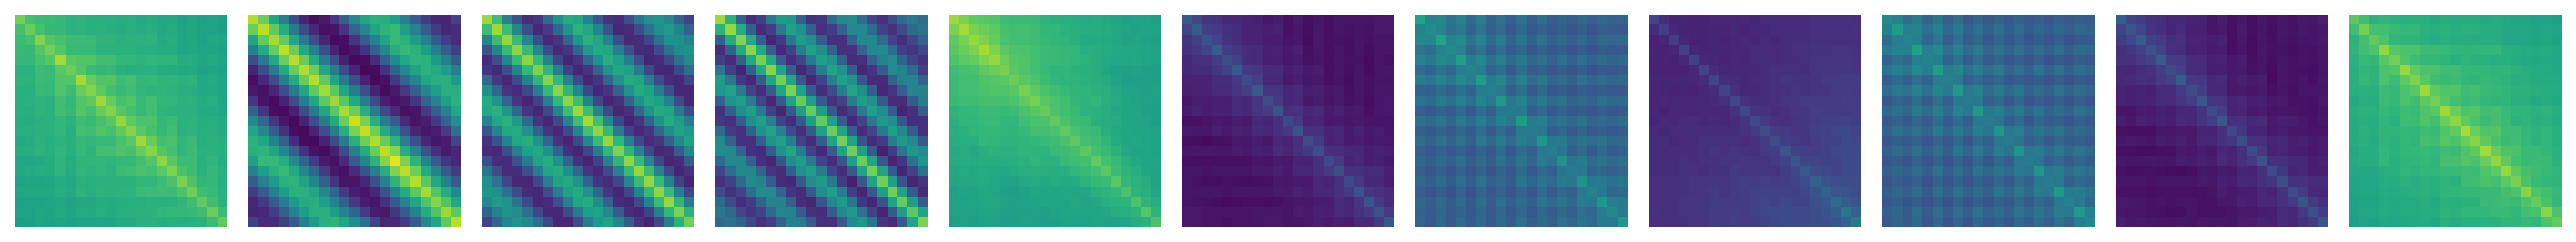

In [45]:
vmin  = np.min([untrunc_covs, hmm_covs])               # global minimum
vmax  = np.max([untrunc_covs, hmm_covs])               # global maximum
norm  = plt.Normalize(vmin, vmax)      # shared normalisation
fig, ax = plt.subplots(1, hmm_covs.shape[0], figsize = (untrunc_covs.shape[0]*2, 2), gridspec_kw = {"wspace":0.1})
for i ,cov in enumerate(hmm_covs):
    ax[i].imshow(cov, cmap = "viridis", norm = norm)
    ax[i].set_axis_off()

fig.savefig(
    f"../figures/{sim_cond}_hmm_covs.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)


/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_29629/4033313953.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


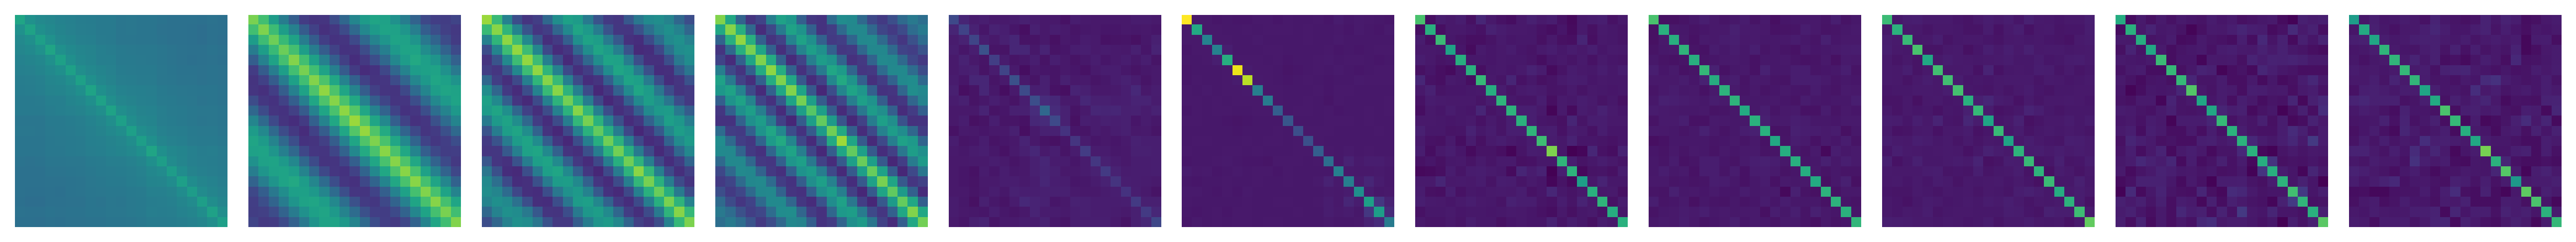

In [46]:

fig, ax = plt.subplots(1, untrunc_covs.shape[0], figsize = (untrunc_covs.shape[0]*2, 2), gridspec_kw = {"wspace":0.1})
for i ,cov in enumerate(untrunc_covs):
    ax[i].imshow(cov,  cmap = "viridis", norm = norm)
    ax[i].set_axis_off()

fig.savefig(
    f"../figures/{sim_cond}_gpgmm_covs.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)


## states before imputation


In [47]:
_gmm_mcc = res.query("method == 'DP-GMM'").mcc.values[0]
_gmm_states = res.query("method == 'DP-GMM'").est_states.to_numpy()[0]
_gmm_states_onehot = np.eye(num_states)[_gmm_states]

_hmm_mcc = res.query("method == 'HMM'").mcc.values[0]
_hmm_states = res.query("method == 'HMM'").est_states.to_numpy()[0]
_hmm_states_onehot = np.eye(num_states)[_hmm_states]


print("dp-gmm", _gmm_mcc)
print("dp-gmm (imputed)", gmm_mcc)

print("hmm", _hmm_mcc)
print("hmm (imputed)", hmm_mcc)


"""
dp-gmm 0.8618107993142023
dp-gmm (imputed) 0.938337224764793
hmm 0.3483492480108877
hmm (imputed) 0.3112647340620908
"""

dp-gmm 0.8693541137545504
dp-gmm (imputed) 0.9350720693206954
hmm 0.3483492480108877
hmm (imputed) 0.3112647340620908


'\ndp-gmm 0.8618107993142023\ndp-gmm (imputed) 0.938337224764793\nhmm 0.3483492480108877\nhmm (imputed) 0.3112647340620908\n'

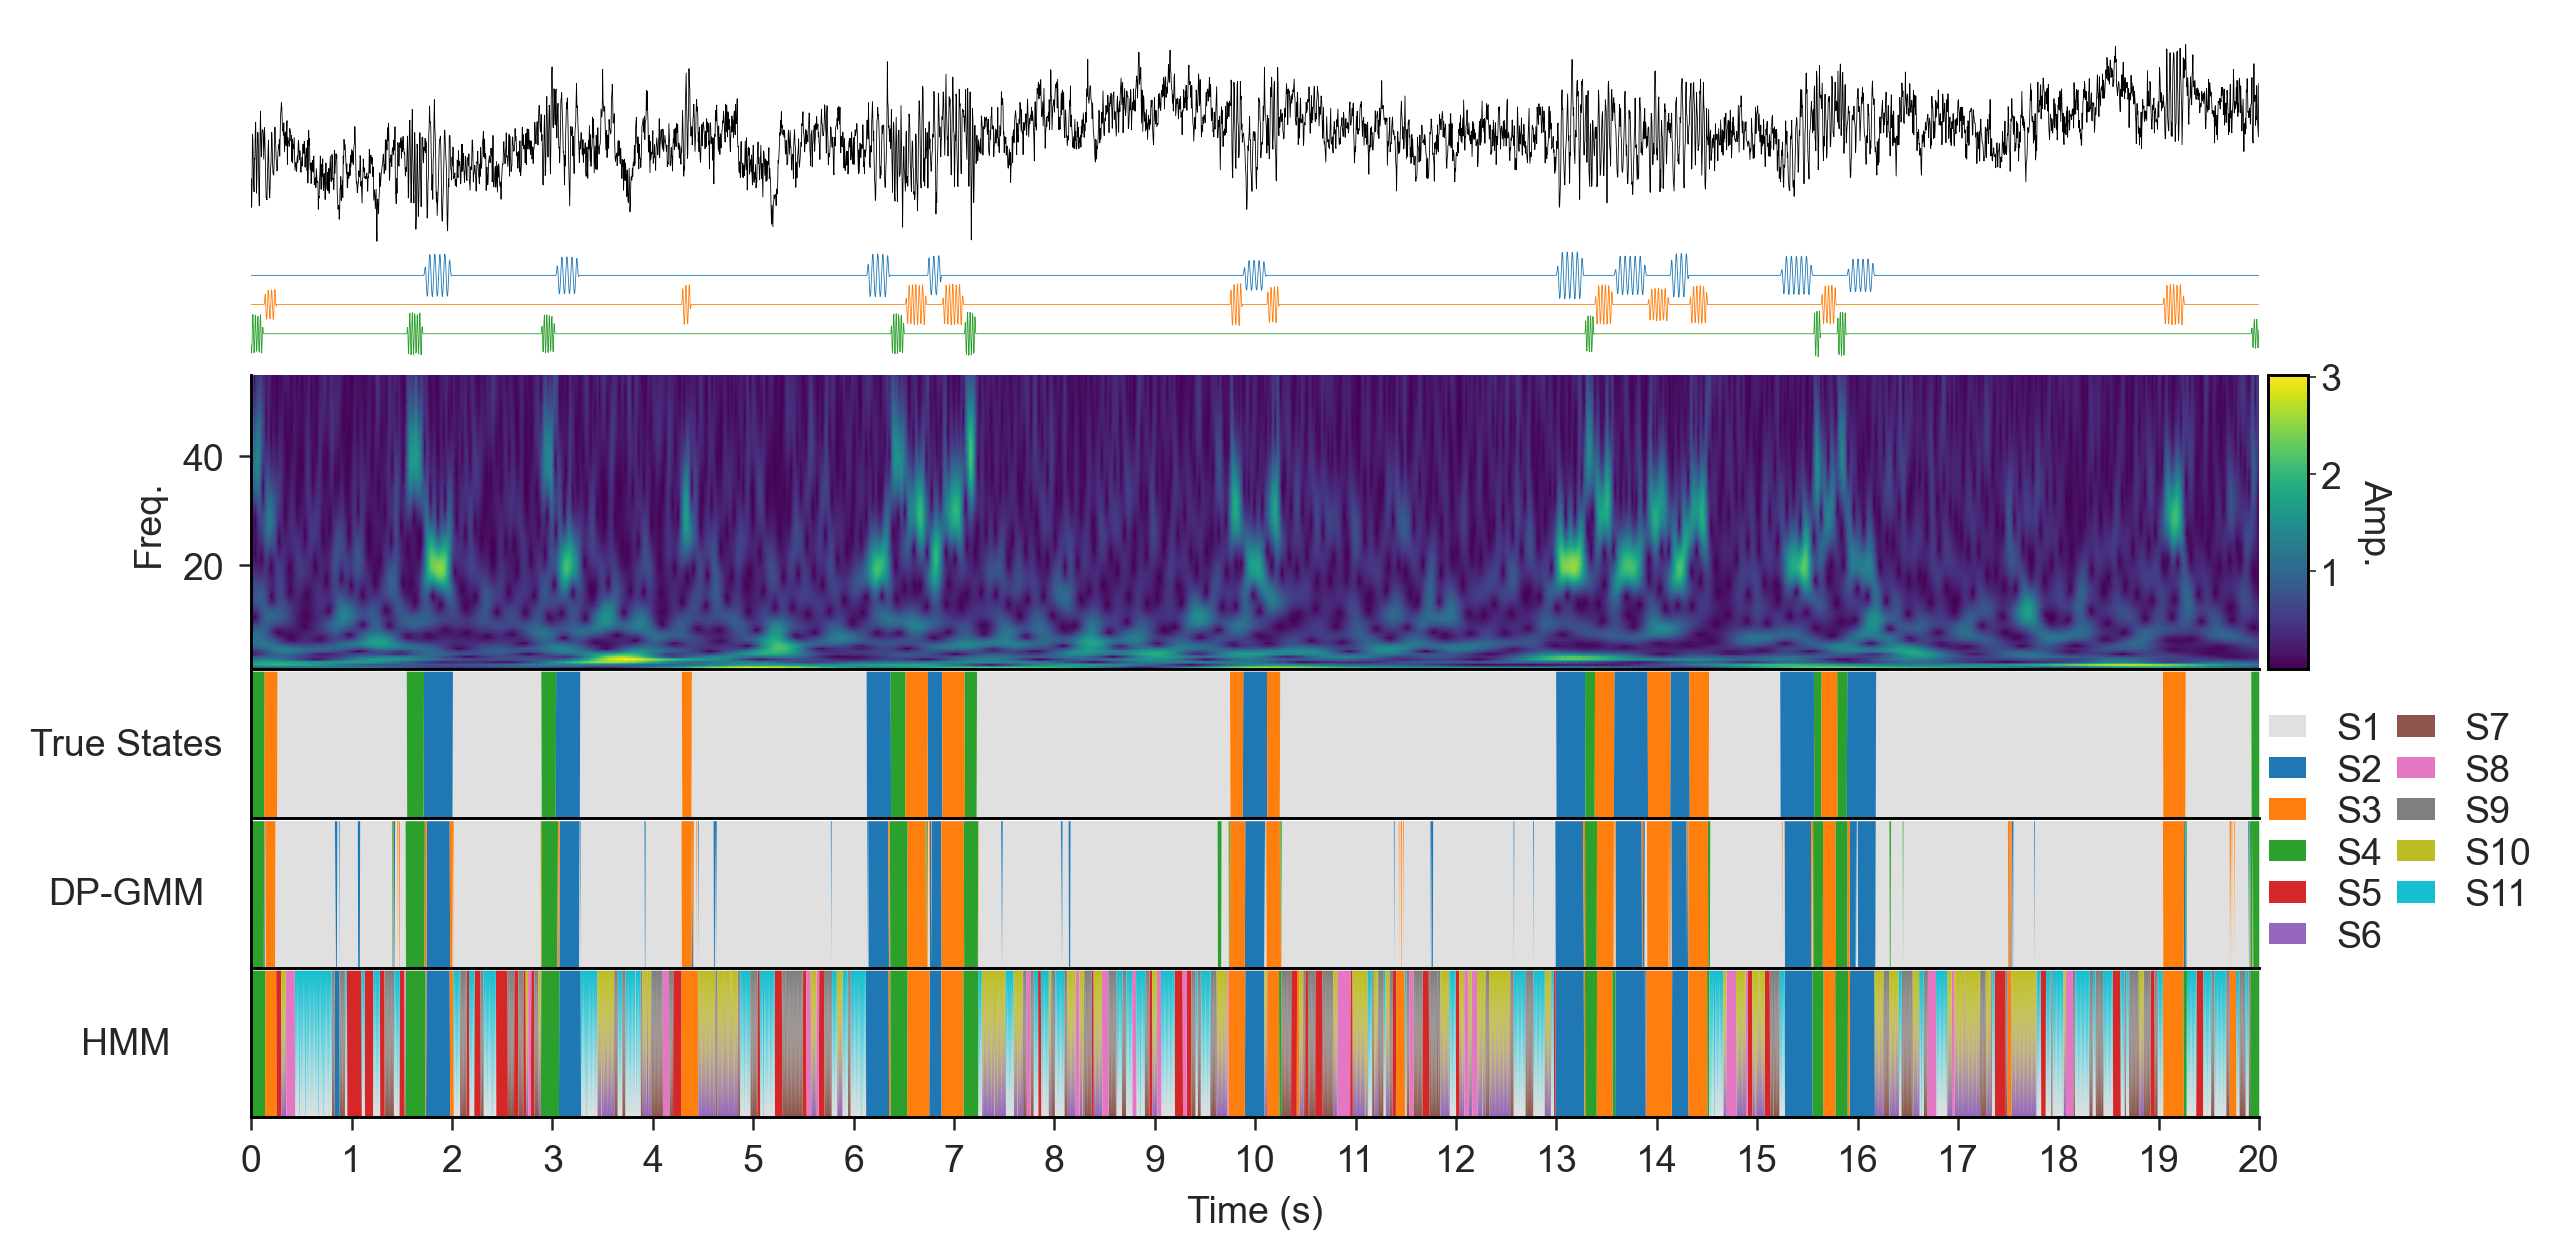

In [51]:

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"S{i+1}" for i in range(num_states)]

plot_t = 20


trimmed_states_onehot = np.eye(num_states)[trimmed_states]
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")

mosaic = [["a1", "a1"],
          ["a2", "a2"],
          ["a3", "a3"],
          ["a4", "a4"],
          ["a5", "a5"],
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 4.),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.3,0.3,0.3]}
)

fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)



axes["a1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["a1"].set_frame_on(False)
#axes["a1"].set_title(f"Raw signal (SNR = {snr_db} dB)",pad= 0.3)

scale_burst = 1.7

axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -5+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1)), lw=0.2, color=colors[1])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -6+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2)), lw=0.2, color=colors[2])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -7+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 3)), lw=0.2, color=colors[3])



axes["a1"].set_yticks([])
axes["a1"].set_xticks([])





#axes["b1"].set_ylabel(f"{plot_f}Hz", fontsize = TINY_SIZE, rotation = 0, labelpad = 20)

for s in ("top","right","bottom","left"):
    axes["a1"].spines[s].set_visible(False)
axes["a1"].set_frame_on(False)
axes["a1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["a2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["a2"].set_ylabel("Freq.")
#axes["a2"].set_title("Wavelet Transform",pad = 0.3)


axes["a2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["a2"].yaxis.set_major_locator(MultipleLocator(20))

axes["a2"].set_ylim(1, 55)
axes["a2"].sharex(axes["a1"])


cax = inset_axes(
    axes["a2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["a3"].stackplot(trimmed_time_vec[:plot_t*fs], trimmed_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["a3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")

axes["a4"].stackplot(trimmed_time_vec[:plot_t*fs], _gmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {_gmm_mcc:.2f}"] + [None]*(num_states-1))
axes["a4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")

axes["a5"].stackplot(trimmed_time_vec[:plot_t*fs], _hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {_hmm_mcc:.2f}")
axes["a5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")



for key in ["a1","a2", "a3", "a4", "a5"]:
    axes[key].sharex(axes["a1"])

for key in ["a3", "a4"]:
    axes[key].tick_params(axis='x', which='both', bottom=True, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    axes[key].set_xlim(0, plot_t)



axes["a5"].set_xlabel("Time (s)")
axes["a5"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["a5"].xaxis.set_minor_locator(MultipleLocator(0.5))
#axes["a5"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["a5"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["a5"].set_ylim(0, 1)
axes["a5"].set_xlim(0, plot_t)


axes["a5"].spines["bottom"].set_visible(True)   # keep x-axis frame




handles, labels = axes["a3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           bbox_to_anchor=(0.98, 0.33), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1,
           handleheight=0.5,
           labelspacing = 0.2,
           ncol = 2,
           columnspacing = 0.4,
           )



fig.savefig(
    f"../figures/{sim_cond}_before_imputation.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)


plt.show()



## HMM

In [55]:
import pickle
save_path = os.path.join(performance_dir, f"{sim_cond}_HMM_results.pkl")

# Load
with open(save_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df = pd.concat(df_list, axis = 0, ignore_index = True)

df.head()


,method,signal,true_states,burst_f,fs,snr,est_params,best_model_id,loss_best,loss_all,fit_t,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss
0,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.74486524, 0.25513476], 't...",7,0.546423,"[[1.4314460714299742, 1.250953059730719, 1.151...",73.301494,0.523111,73.824605,2,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0]",None,None,0.546423
1,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.62651044, 0.20530105, 0.1...",2,0.539855,"[[1.6324689039241207, 1.2568464254477476, 1.15...",48.039872,0.367093,48.406966,3,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 2, 1]",None,None,0.539855
2,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.40047932, 0.14736506, 0.2...",0,0.530635,"[[1.4887848861504835, 1.4236964855674614, 1.27...",86.767325,0.171692,86.939017,4,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2, 1, 3, 0]",None,None,0.530635
3,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.32911584, 0.18618357, 0.1...",4,0.527656,"[[1.4836739567833206, 1.2856269277421006, 1.31...",106.047387,0.188655,106.236042,5,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[4, 2, 0, 3, 1]",None,None,0.527656
4,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.20053026, 0.22559878, 0.2...",3,0.518811,"[[1.5965215600881493, 1.1739165587918023, 1.13...",139.007899,0.206383,139.214281,6,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[1, 0, 4, 3, 5, 2]",None,None,0.518811


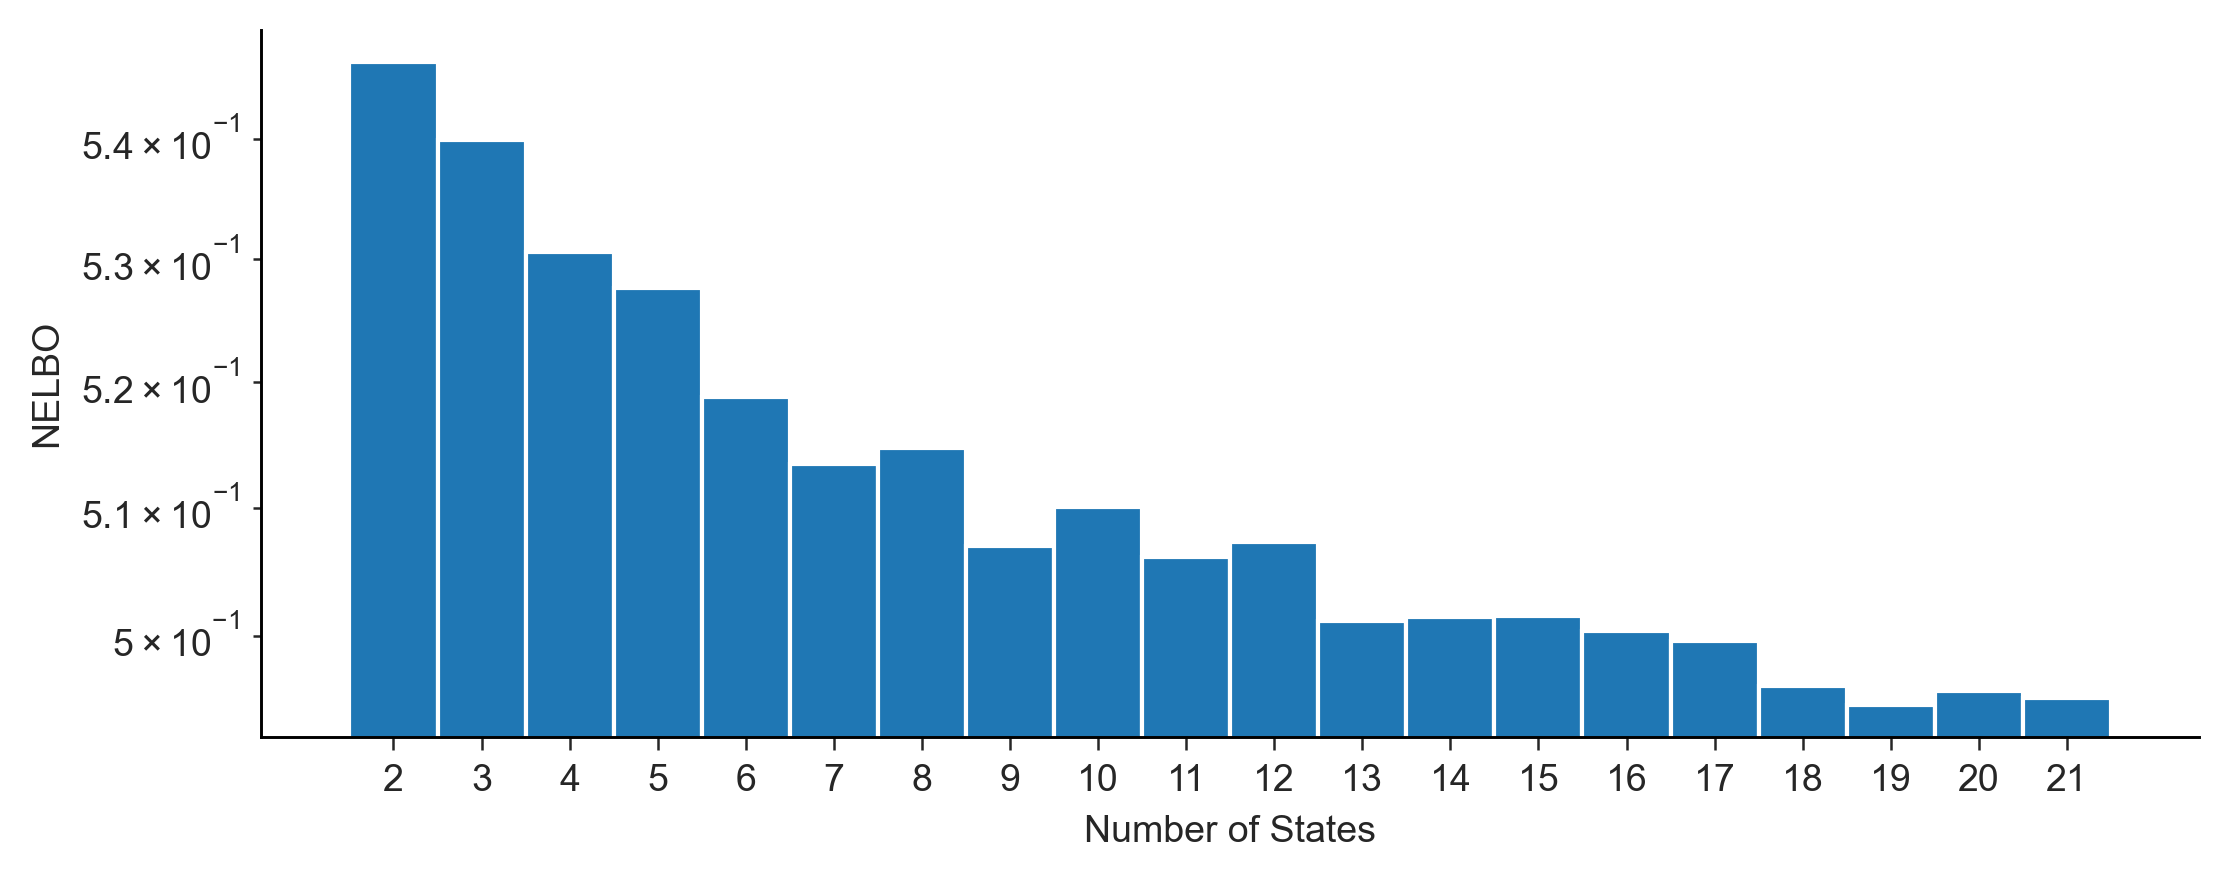

In [58]:
hmm_res = df.query("method == 'HMM'")
num_states_vec = hmm_res.num_states.to_numpy().astype(int)


hmm_color   = "#1f77b4"



elbos = hmm_res["loss_best"]
fig, ax = plt.subplots(figsize = (FIG_WIDTH, 3))
ax.bar(num_states_vec, elbos, color = hmm_color, width = 1, align = "center")
ax.set_yscale("log")
ax.set_xticks(num_states_vec)
ax.set_ylabel("NELBO")
ax.set_xlabel("Number of States")


fig.savefig(
    f"../figures/{sim_cond}_HMM_nelbo.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)






